# Edge Intelligence

## Setup en configuratie

In [ ]:
# Standaard pip installatie
%pip install pandas numpy matplotlib scikit-learn tensorflow seaborn plotly statsmodels missingno

In [ ]:
# Basisbibliotheken voor dataverwerking
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Visualisatie
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px  # Voor interactieve visualisaties

# Data preprocessing
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Voor tijdreeks specifieke functionaliteit
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose

# Deep learning met Keras/TensorFlow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout, BatchNormalization, RNN, LSTMCell
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import Sequence
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator


# Voor het verdelen van de dataset
from sklearn.model_selection import TimeSeriesSplit

# Voor gapdetectie en -analyse
import missingno as msno

from google.colab import drive, files
import psutil

In [ ]:
print(tf.__version__)
print(np.__version__)

2.18.0
2.0.2


In [ ]:
# Basispaden
# DATA_PATH = './output.csv'
drive.mount('/content/drive')
DATA_PATH = 'drive/MyDrive/MasterProef/data/home.csv'
MODEL_SAVE_PATH = './models/home_lstm_model.keras'

# Tijdreeks parameters
SAMPLING_INTERVAL = 5
RESAMPLE_INTERVAL = '5s'  # 5-seconden interval voor consistente sampling
FORECAST_HORIZON = 60 * 60 // SAMPLING_INTERVAL  # Aantal intervallen in een uur (voorspellingsvenster)
LOOKBACK_WINDOW = 12 * 60 // SAMPLING_INTERVAL  # Aantal intervallen voor 12 minuten terugkijken

# Gap-behandelingsparameters
SMALL_GAP = 10        # Gaten tot 10 seconden (kleine onregelmatigheden)
MEDIUM_GAP = 5 * 60  # Gaten tot 5 minuten (kunnen worden geïnterpoleerd)
LARGE_GAP = 60 * 60   # Gaten tot 1 uur (voorzichtig interpoleren)
HUGE_GAP = 24 * 60 * 60  # Gaten groter dan een dag (speciale behandeling nodig)

# LSTM modelparameters
BATCH_SIZE = 100
EPOCHS = 10
LSTM_UNITS = 32
DROPOUT_RATE = 0.2
LEARNING_RATE = 0.001

# Trainingsparameters
TRAIN_SPLIT = 0.7
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15

Mounted at /content/drive


## Data inladen en configuratie

In [ ]:
# HOME DATA BLOCK
df = pd.read_csv(DATA_PATH, comment='#', skip_blank_lines=True)

# Verwijder tijdzone en rond af
df['_time'] = pd.to_datetime(df['_time'], errors='coerce', utc=True).dt.tz_localize(None)
df['_time'] = df['_time'].dt.round('s')

df_selected = df[['_time', '_value']].copy()

# Hernoem kolommen
df_selected.columns = ['Datetime', 'Power_Value']

print(f"Originele dataframe vorm: {df.shape}")
print(f"Kolommen in het originele dataframe: {df.columns.tolist()}")

# Controleer datumbereik
min_date = df_selected['Datetime'].min()
max_date = df_selected['Datetime'].max()
date_range = max_date - min_date

print(f"Datumbereik: van {min_date} tot {max_date}")
print(f"Totale tijdsduur: {date_range}")
print(f"Aantal dagen: {date_range.days}")

FileNotFoundError: [Errno 2] No such file or directory: 'drive/MyDrive/MasterProef/data/home.csv'

In [ ]:
#  CODE BLOK TOM

# Laad CSV met tijdreeksgegevens (15s intervallen)
df = pd.read_csv('drive/MyDrive/MasterProef/data/training_tom.csv', parse_dates=['Datetime'])

# Afronden op seconden voor zekerheid
df['Datetime'] = pd.to_datetime(df['Datetime'], errors='coerce').dt.round('s')

# Zorg ervoor dat Power_Value numeriek is
df['Power_Value'] = pd.to_numeric(df['Power_Value'], errors='coerce')

# Negatieve waarden op nul zetten
df.loc[df['Power_Value'] < 0, 'Power_Value'] = 0

# Kopie van het relevante dataframe
df_selected = df[['Datetime', 'Power_Value']].copy()

# Controle: vorm en datumbereik
print(f"Originele dataframe vorm: {df.shape}")
print(f"Geselecteerde dataframe vorm: {df_selected.shape}")

min_date = df_selected['Datetime'].min()
max_date = df_selected['Datetime'].max()
date_range = max_date - min_date

print(f"Datumbereik: van {min_date} tot {max_date}")
print(f"Totale tijdsduur: {date_range}")
print(f"Aantal dagen: {date_range.days}")

# Bereken verschil in tijd tussen metingen
df_selected['time_diff'] = df_selected['Datetime'].diff().dt.total_seconds()

# Statistieken over meetintervallen
print("Statistieken over tijd tussen metingen (seconden):")
print(df_selected['time_diff'].describe())


In [ ]:
# CODE BLOK KTN

# Laad de data
df = pd.read_csv(DATA_PATH, comment='#', skip_blank_lines=True)

# Converteer Datetime naar correct formaat
df['Datetime'] = pd.to_datetime(df['Datetime'], errors='coerce')

# De kolommen zijn al juist benoemd, dus geen hernoemen nodig

print(f"Originele dataframe vorm: {df.shape}")
print(f"Kolommen in het originele dataframe: {df.columns.tolist()}")

# Controleer datumbereik
min_date = df['Datetime'].min()
max_date = df['Datetime'].max()
date_range = max_date - min_date

print(f"Datumbereik: van {min_date} tot {max_date}")
print(f"Totale tijdsduur: {date_range}")
print(f"Aantal dagen: {date_range.days}")

df_selected = df.copy()

In [ ]:
# Bereken tijd tussen opeenvolgende metingen
df_selected['time_diff'] = df_selected['Datetime'].diff().dt.total_seconds()

# Statistieken over de tijd tussen metingen
print("Statistieken over tijd tussen metingen (seconden):")
print(df_selected['time_diff'].describe())

# Visualiseer distributie van de tijdsverschillenn
plt.figure(figsize=(12, 6))
plt.hist(df_selected['time_diff'].dropna(), bins=50)
plt.title('Distributie van tijd tussen opeenvolgende metingen')
plt.xlabel('Tijd (seconden)')
plt.ylabel('Frequentie')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Plot de raw data
plt.figure(figsize=(15, 5))

plt.plot(df_selected.Datetime, df_selected.Power_Value)
plt.title('Plot raw data')
plt.xticks(rotation=30, ha='right')
plt.xlabel('Date')
plt.ylabel('Power Value')

In [ ]:
# Voeg tijdscomponenten toe
df_selected['hour'] = df_selected['Datetime'].dt.hour
df_selected['day'] = df_selected['Datetime'].dt.day
df_selected['month'] = df_selected['Datetime'].dt.month
df_selected['dayofweek'] = df_selected['Datetime'].dt.dayofweek

# Gemiddelde energiewaarde per uur van de dag
hourly_avg = df_selected.groupby('hour')['Power_Value'].mean()

plt.figure(figsize=(12, 6))
hourly_avg.plot(kind='bar')
plt.title('Gemiddelde energiewaarde per uur van de dag')
plt.xlabel('Uur')
plt.ylabel('Gemiddelde Power_Value')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Bereken aantal metingen per dag
daily_counts = df_selected.groupby(df_selected['Datetime'].dt.date).size()

# Plot het aantal metingen per dag
plt.figure(figsize=(15, 6))
daily_counts.plot(kind='bar')
plt.title('Aantal metingen per dag')
plt.xlabel('Datum')
plt.ylabel('Aantal metingen')
plt.grid(True, axis='y', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Berekenen van het theoretische aantal metingen per dag bij een 3-seconden interval (zoals in de datacollectie ingesteld staat)
seconds_per_day = 24 * 60 * 60
expected_daily_samples = seconds_per_day / SAMPLING_INTERVAL

print(f"Theoretisch aantal metingen per dag bij 3s interval: {expected_daily_samples}")
print("Werkelijk aantal metingen per dag:")
print(daily_counts)
print("\nVolledigheid per dag (percentage van theoretisch maximum):")
completeness = (daily_counts / expected_daily_samples) * 100
print(completeness)

In [ ]:
# Maak perfect geresamplede tijdsreeks op 5s interval
perfect_range = pd.date_range(start=min_date, end=max_date, freq='5s')
perfect_df = pd.DataFrame(index=perfect_range)

# Merge data met perfecte tijdreeks
merged_df = perfect_df.join(df_selected.set_index('Datetime'), how='left')

# Visualiseer de ontbrekende waarden
plt.figure(figsize=(15, 8))
msno.matrix(merged_df, freq='1D', color=(0.1, 0.3, 0.6))
plt.title('Patroon van ontbrekende waarden per dag')
plt.show()

In [ ]:
# Identificeer alle gaten die groter zijn dan een bepaalde drempel
large_gaps = df_selected[df_selected['time_diff'] > MEDIUM_GAP]

print(f"Aantal grote gaten (> {MEDIUM_GAP} seconden): {len(large_gaps)}")
if not large_gaps.empty:
    print("\nTop 10 grootste gaten:")
    large_gaps_sorted = large_gaps.sort_values('time_diff', ascending=False)
    for idx, row in large_gaps_sorted.head(10).iterrows():
        gap_duration = timedelta(seconds=row['time_diff'])
        print(f"Gap op {row['Datetime']}: {gap_duration} ({row['time_diff']} seconden)")

# Visualiseer distributie van grote gaten
if not large_gaps.empty:
    plt.figure(figsize=(12, 6))
    plt.hist(large_gaps['time_diff'] / 60, bins=30)  # Converteer naar minuten
    plt.title('Distributie van grote gaten (> 5 minuten)')
    plt.xlabel('Gatgrootte (minuten)')
    plt.ylabel('Frequentie')
    plt.grid(True, alpha=0.3)
    plt.show()

## Data cleaning

Date: 2025-02-17, Raw Data Points: 24857, Cleaned Data Points: 24857


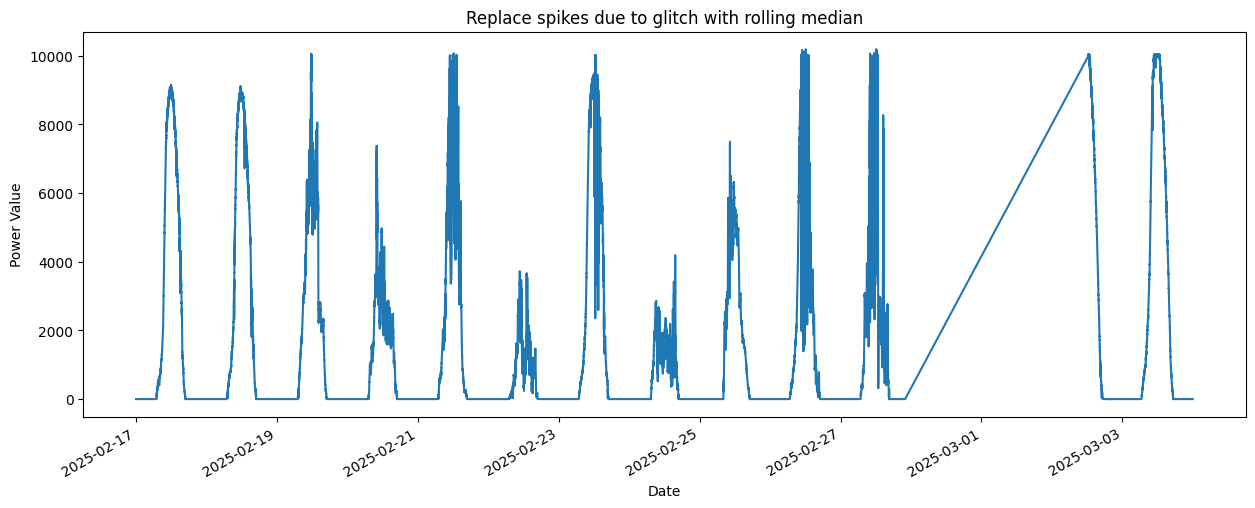

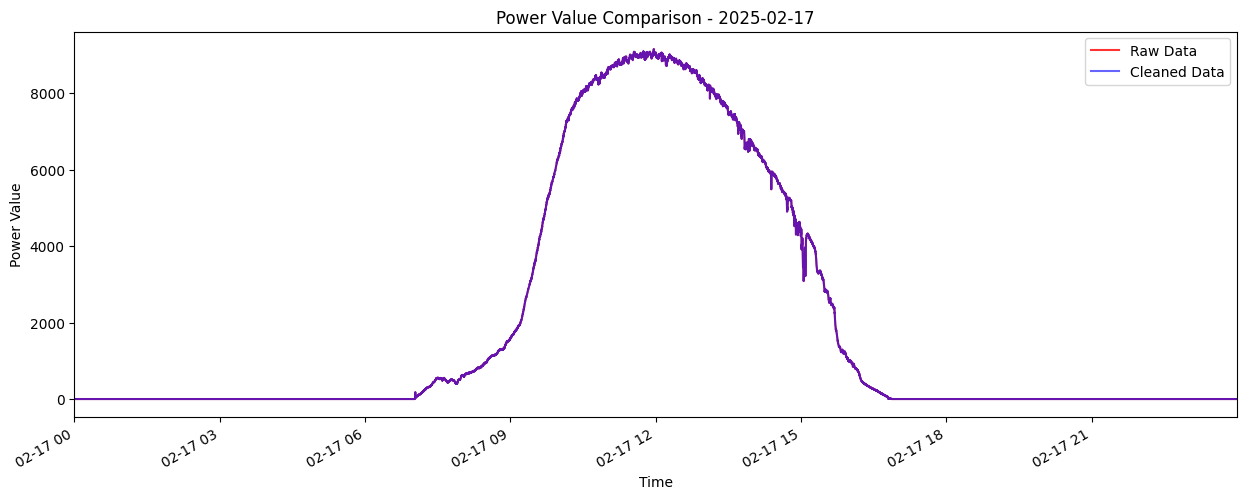

Date: 2025-02-18, Raw Data Points: 24703, Cleaned Data Points: 24703


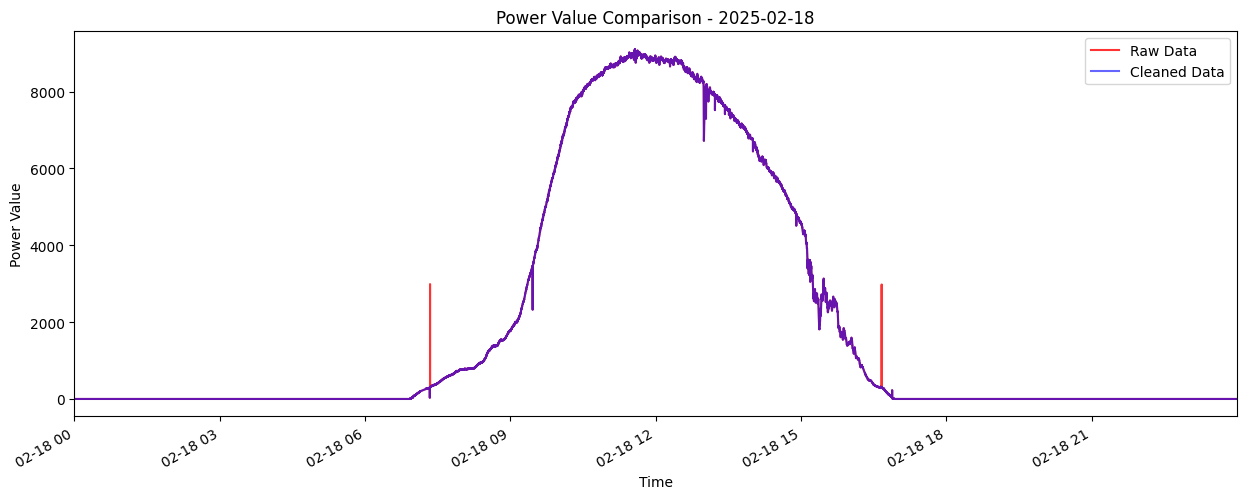

Date: 2025-02-19, Raw Data Points: 24639, Cleaned Data Points: 24639


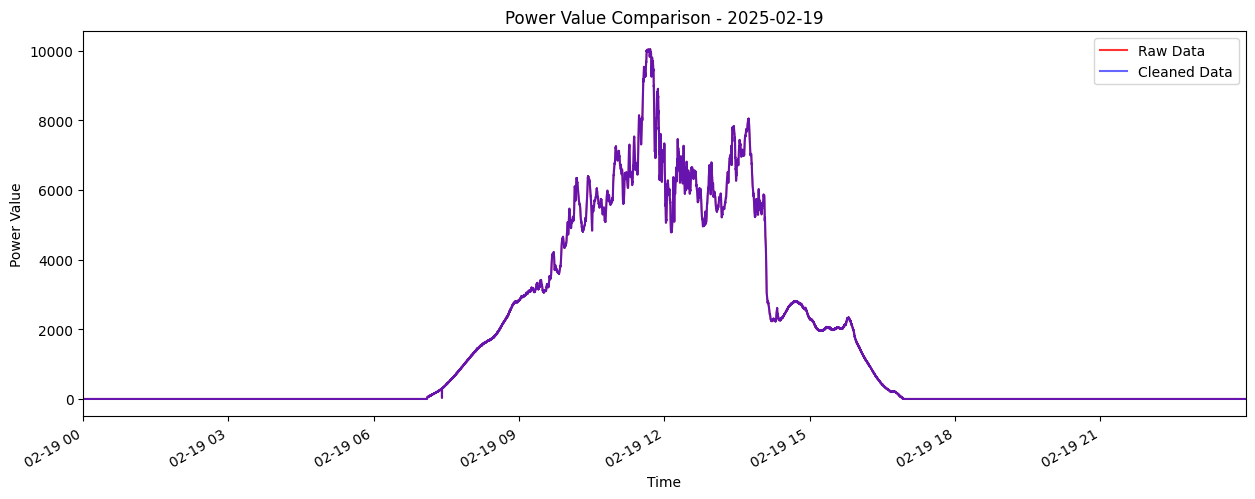

Date: 2025-02-20, Raw Data Points: 24730, Cleaned Data Points: 24730


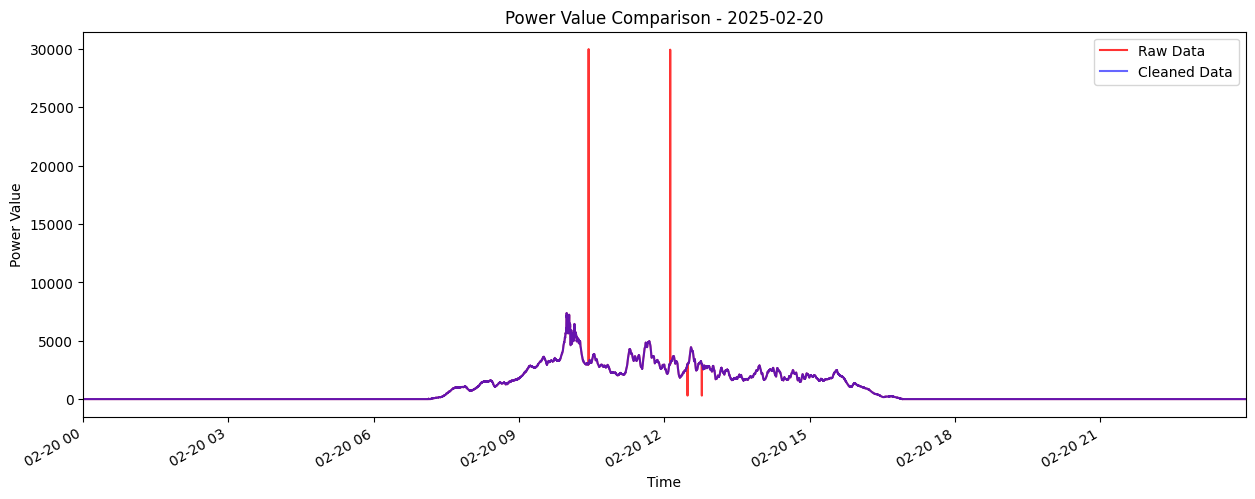

Date: 2025-02-21, Raw Data Points: 25126, Cleaned Data Points: 25126


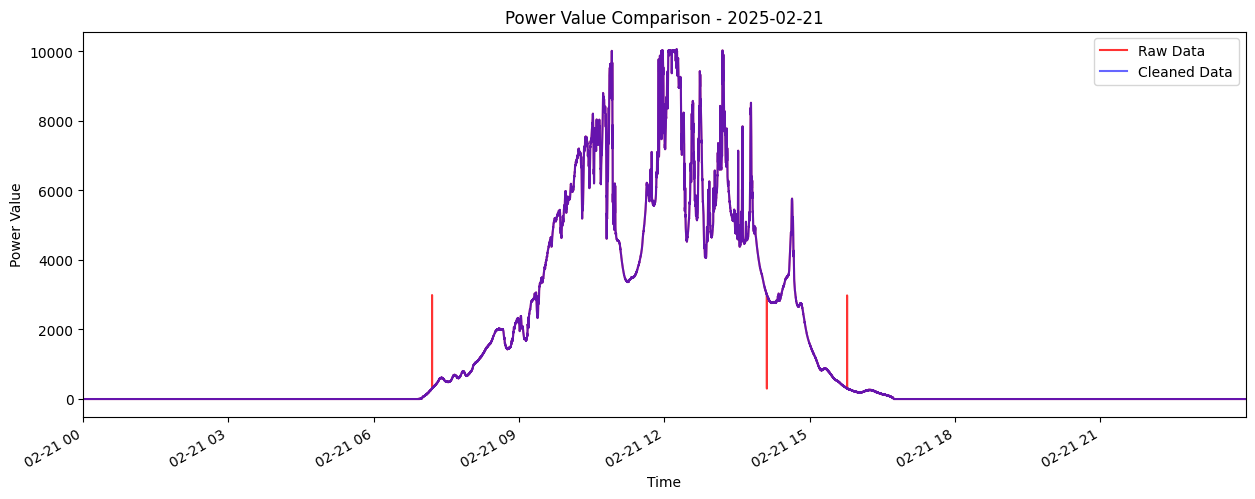

Date: 2025-02-22, Raw Data Points: 24352, Cleaned Data Points: 24352


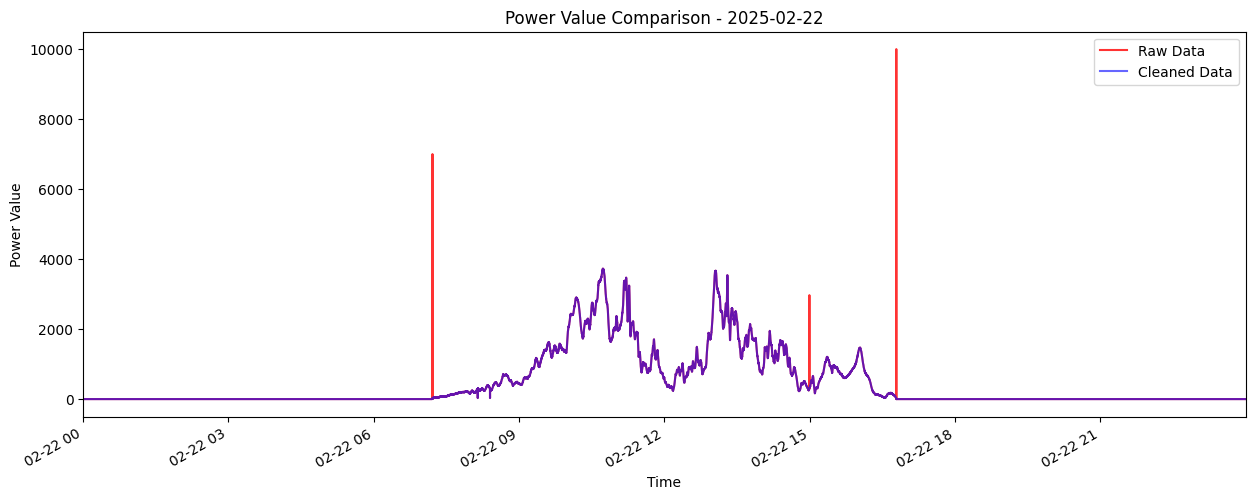

Date: 2025-02-23, Raw Data Points: 24412, Cleaned Data Points: 24412


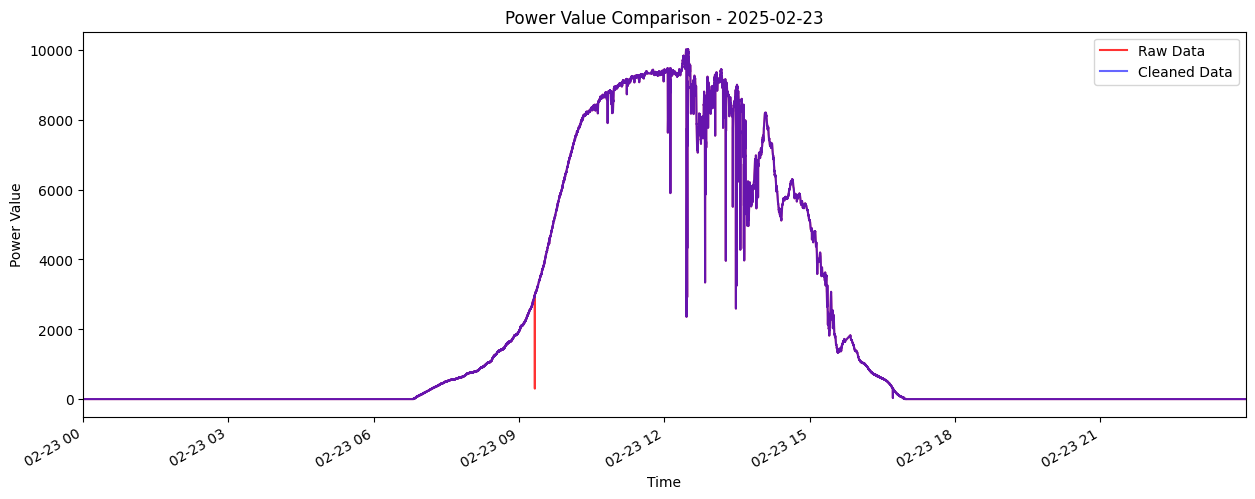

Date: 2025-02-24, Raw Data Points: 23603, Cleaned Data Points: 23603


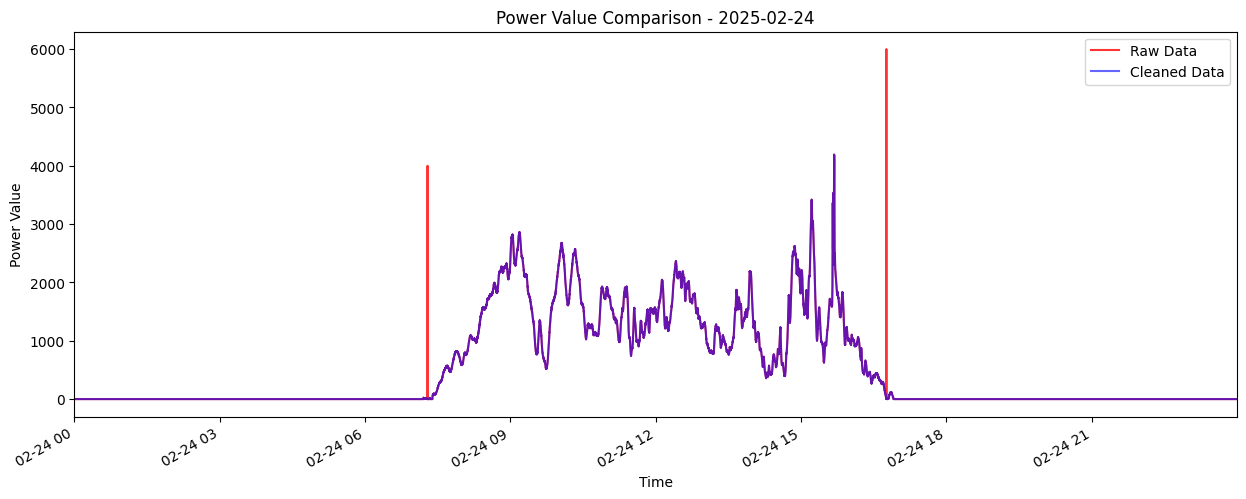

Date: 2025-02-25, Raw Data Points: 23988, Cleaned Data Points: 23988


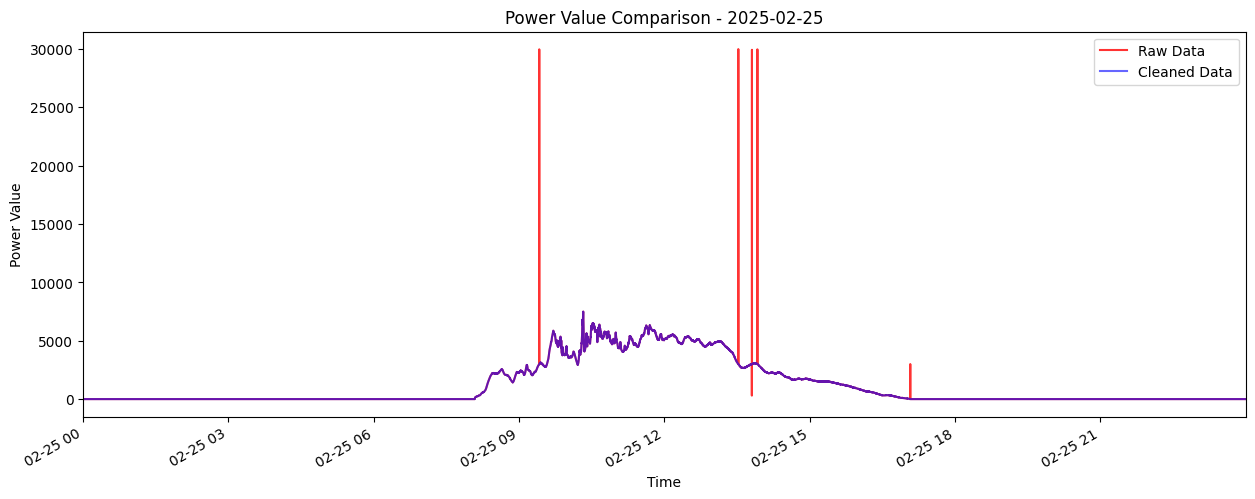

Date: 2025-02-26, Raw Data Points: 24549, Cleaned Data Points: 24549


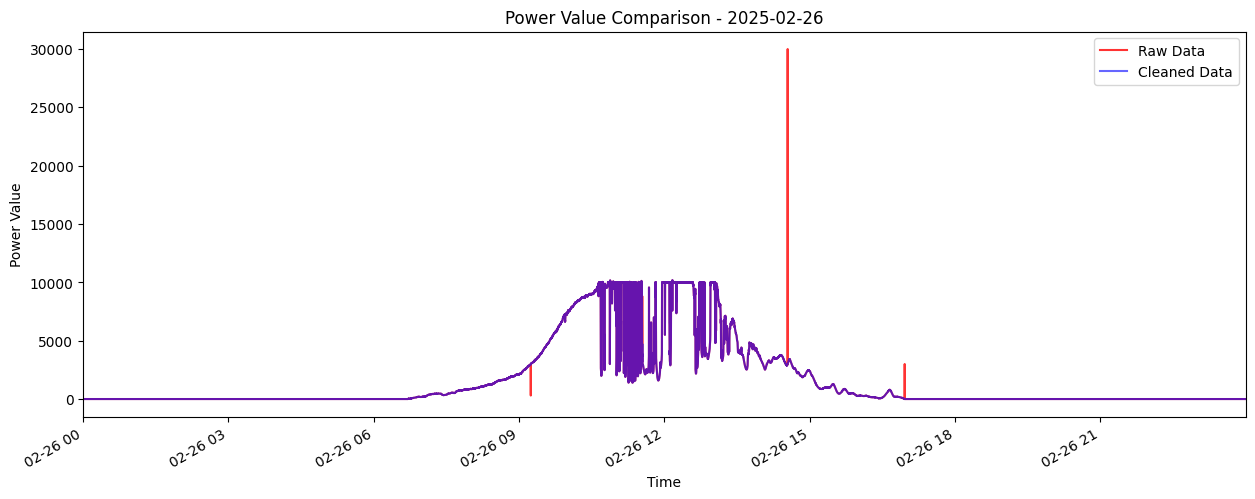

Date: 2025-02-27, Raw Data Points: 22784, Cleaned Data Points: 22784


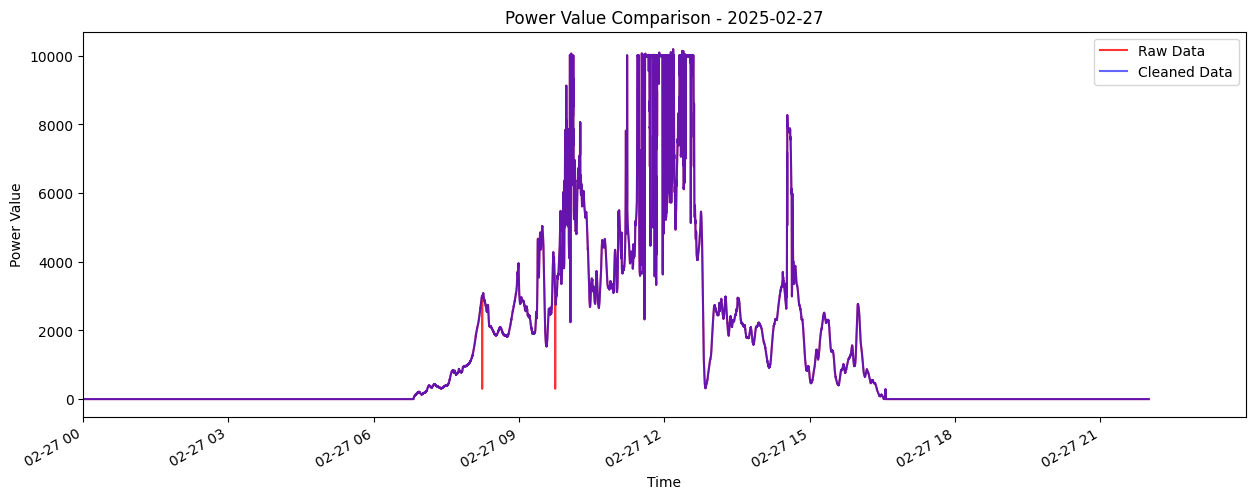

Date: 2025-02-28, Raw Data Points: 0, Cleaned Data Points: 0
Date: 2025-03-01, Raw Data Points: 0, Cleaned Data Points: 0
Date: 2025-03-02, Raw Data Points: 11999, Cleaned Data Points: 11999


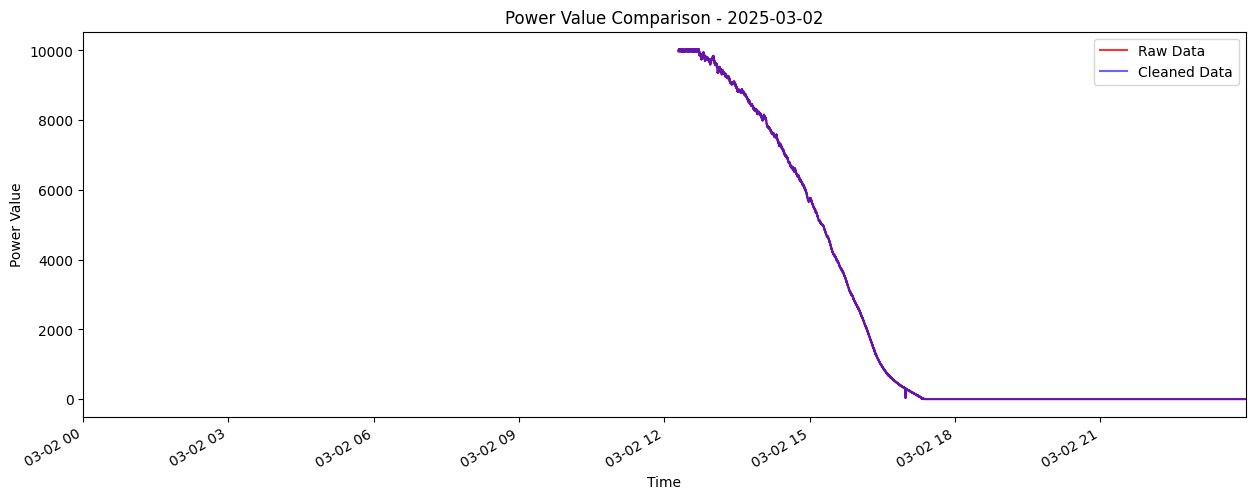

Date: 2025-03-03, Raw Data Points: 24864, Cleaned Data Points: 24864


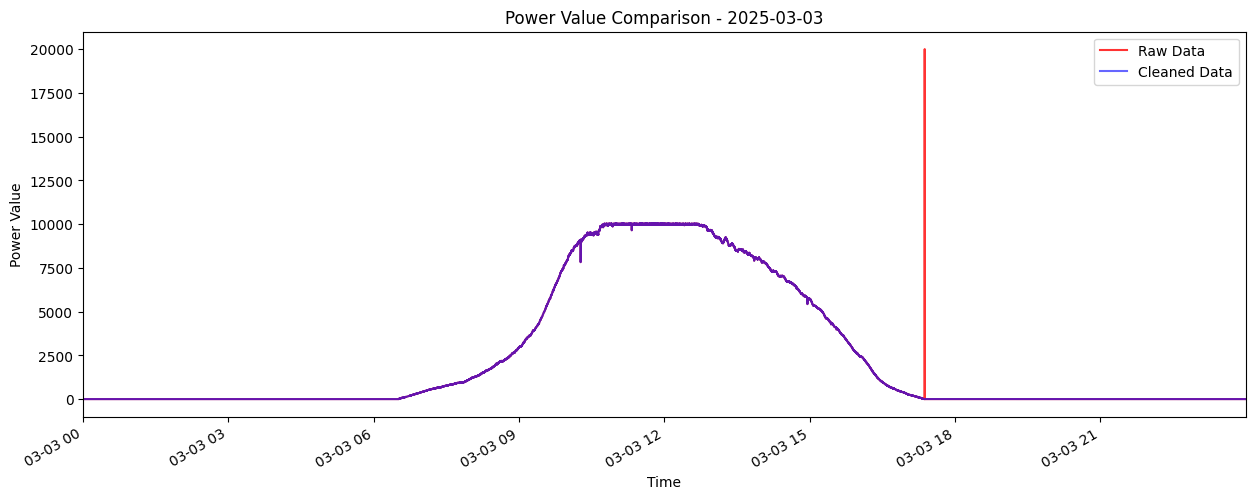

In [ ]:
# Verwijderen glitch spikes mbv rolling median
window_size = 3
threshold_factor = 0.85
min_threshold = 2500

df_cleaned = df_selected.copy()

# Bereken rolling median en vul NaNs
df_cleaned["rolling_median"] = df_cleaned["Power_Value"].rolling(window=window_size, center=True).median()
df_cleaned["rolling_median"] = df_cleaned["rolling_median"].bfill().ffill()

# Bereken afwijking van mediaan
df_cleaned["deviation"] = np.abs(df_cleaned["Power_Value"] - df_cleaned["rolling_median"])

# Bepaal threshold
threshold = np.maximum(df_cleaned["rolling_median"] * threshold_factor, min_threshold)

# Vind uitschieters
df_cleaned["outlier"] = df_cleaned["deviation"] > threshold

# Vervang uitschieters met rolling median
df_cleaned.loc[df_cleaned["outlier"], "Power_Value"] = (
    df_cleaned["rolling_median"].fillna(df_cleaned["Power_Value"].median()).astype(df_cleaned["Power_Value"].dtype)
)

# Cleanup
df_cleaned = df_cleaned.drop(columns=["rolling_median", "deviation", "outlier"])

# Plot
plt.figure(figsize=(15, 5))
plt.plot(df_cleaned.Datetime, df_cleaned.Power_Value)
plt.title('Replace spikes due to glitch with rolling median')
plt.xticks(rotation=30, ha='right')
plt.xlabel('Date')
plt.ylabel('Power Value')

# Controleer elke dag visueel
start_date = pd.Timestamp("2025-02-17")
end_date = pd.Timestamp("2025-03-03")


for single_date in pd.date_range(start=start_date, end=end_date, freq='D'):
    day_start = single_date
    day_end = single_date + pd.Timedelta(days=1) - pd.Timedelta(seconds=1)

    # Filter data
    df_raw_day = df_selected[(df_selected["Datetime"] >= day_start) & (df_selected["Datetime"] <= day_end)]
    df_clean_day = df_cleaned[(df_cleaned["Datetime"] >= day_start) & (df_cleaned["Datetime"] <= day_end)]

    print(f"Date: {single_date.date()}, Raw Data Points: {len(df_raw_day)}, Cleaned Data Points: {len(df_clean_day)}")

    # Plot als er data voor die dag is
    if not df_raw_day.empty or not df_clean_day.empty:
        plt.figure(figsize=(15, 5))

        # Plot raw data
        if not df_raw_day.empty:
            plt.plot(df_raw_day.Datetime, df_raw_day.Power_Value, label="Raw Data", color="red", alpha=0.8)

        # Plot cleaned data
        if not df_clean_day.empty:
            plt.plot(df_clean_day.Datetime, df_clean_day.Power_Value, label="Cleaned Data", color="blue", alpha=0.6)

        plt.title(f'Power Value Comparison - {single_date.date()}')
        plt.xlabel('Time')
        plt.ylabel('Power Value')
        plt.xticks(rotation=30, ha='right')
        plt.xlim(day_start, day_end)
        plt.legend()
        plt.show()

## Analyse van datadekking en gaten

In [ ]:
# Zorg dat data chronologisch is
df_cleaned = df_cleaned.sort_values('Datetime')

# Classificeer de gaten
df_cleaned['gap_category'] = pd.cut(
    df_cleaned['time_diff'],
    bins=[0, SMALL_GAP, MEDIUM_GAP, LARGE_GAP, HUGE_GAP, float('inf')],
    labels=['normaal', 'klein', 'middel', 'groot', 'enorm']
)

# Toon statistieken over de gaten
gap_stats = df_cleaned['gap_category'].value_counts().sort_index()
print("Classificatie van gaten in de dataset:")
print(gap_stats)

# Analyse middel, grote en enorme gaten
significant_gaps = df_cleaned[df_cleaned['gap_category'].isin(['middel', 'groot', 'enorm'])]
if not significant_gaps.empty:
    print("\nDetails van significante gaten:")
    for idx, row in significant_gaps.iterrows():
        start_time = row['Datetime'] - pd.Timedelta(seconds=row['time_diff'])
        end_time = row['Datetime']
        duration = pd.Timedelta(seconds=row['time_diff'])

        print(f"Categorie: {row['gap_category']}")
        print(f"  Start: {start_time}")
        print(f"  Eind:  {end_time}")
        print(f"  Duur:  {duration} ({row['time_diff']} seconden)")
        print("  " + "-"*50)

Classificatie van gaten in de dataset:
gap_category
normaal    304243
klein         351
middel          9
groot           0
enorm           1
Name: count, dtype: int64

Details van significante gaten:
Categorie: middel
  Start: 2025-02-18 07:08:28
  Eind:  2025-02-18 07:15:10
  Duur:  0 days 00:06:42 (402.0 seconden)
  --------------------------------------------------
Categorie: middel
  Start: 2025-02-19 06:15:56
  Eind:  2025-02-19 06:21:11
  Duur:  0 days 00:05:15 (315.0 seconden)
  --------------------------------------------------
Categorie: middel
  Start: 2025-02-20 06:42:09
  Eind:  2025-02-20 06:47:13
  Duur:  0 days 00:05:04 (304.0 seconden)
  --------------------------------------------------
Categorie: middel
  Start: 2025-02-22 19:47:51
  Eind:  2025-02-22 19:52:54
  Duur:  0 days 00:05:03 (303.0 seconden)
  --------------------------------------------------
Categorie: middel
  Start: 2025-02-23 11:38:58
  Eind:  2025-02-23 11:44:07
  Duur:  0 days 00:05:09 (309.0 seconde

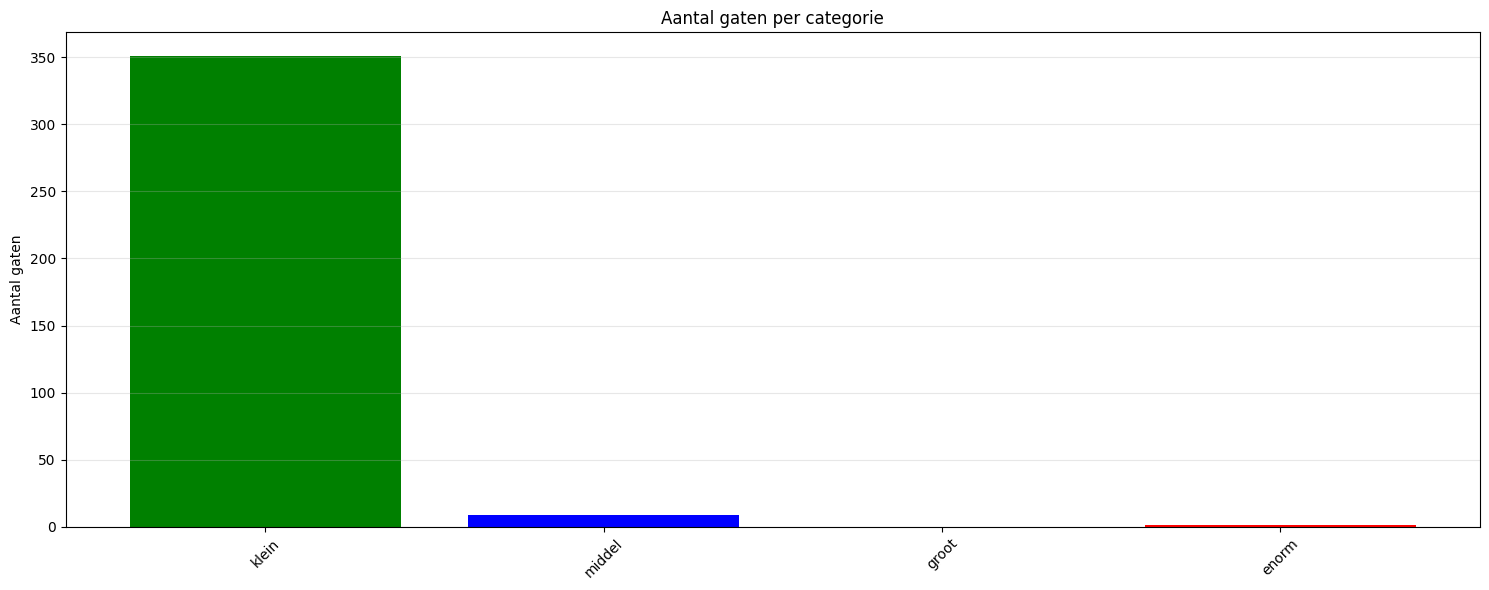

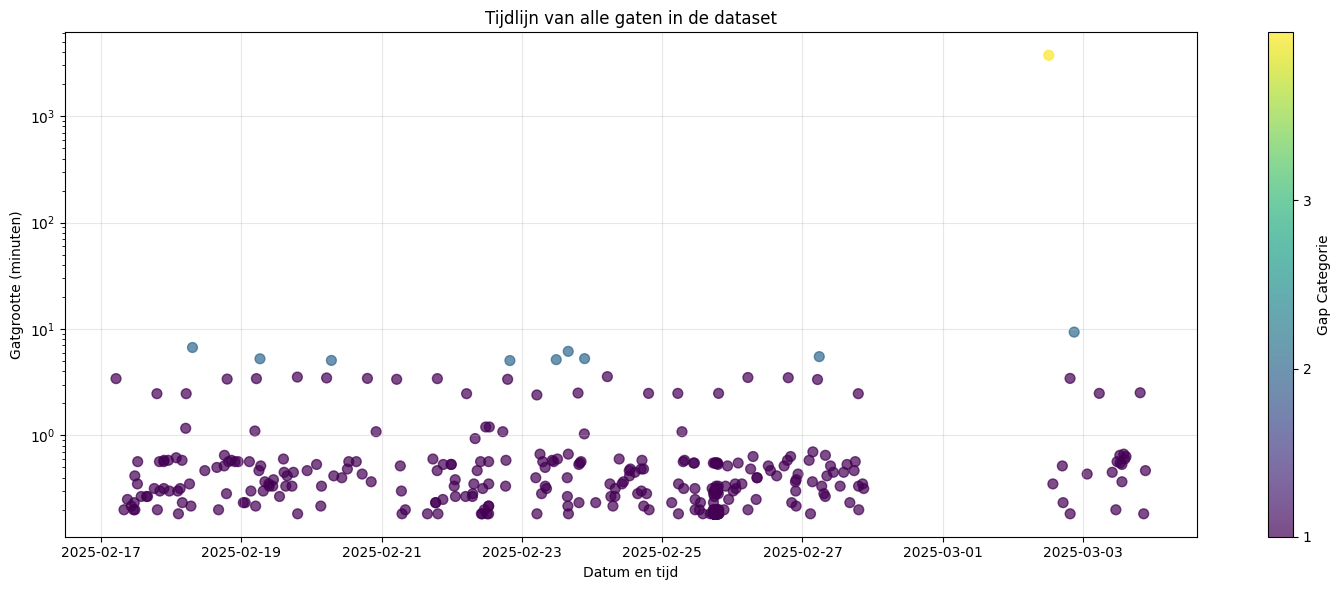

In [ ]:
filtered_gap_stats = gap_stats[gap_stats.index != "normaal"]
# Visualiseer de verdeling van gaten
plt.figure(figsize=(15, 6))
plt.bar(filtered_gap_stats.index, filtered_gap_stats.values, color=['green', 'blue', 'orange', 'red'])
plt.title('Aantal gaten per categorie')
plt.ylabel('Aantal gaten')
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Visualiseer grote gaten op tijdlijn
plt.figure(figsize=(15, 6))
plt.scatter(
    df_cleaned.loc[df_cleaned['gap_category'] != 'normaal', 'Datetime'],
    df_cleaned.loc[df_cleaned['gap_category'] != 'normaal', 'time_diff'] / 60,  # Converteren naar minuten
    c=df_cleaned.loc[df_cleaned['gap_category'] != 'normaal', 'gap_category'].astype('category').cat.codes,
    cmap='viridis',
    alpha=0.7,
    s=50
)
plt.colorbar(label='Gap Categorie', ticks=[0, 1, 2, 3])
plt.title('Tijdlijn van alle gaten in de dataset')
plt.xlabel('Datum en tijd')
plt.ylabel('Gatgrootte (minuten)')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Resampling en gap handling

In [ ]:
df_interpolated = df_cleaned.copy()

print(f"Unieke waarden in Datetime: {df_interpolated['Datetime'].nunique()}")
print(f"Totaal aantal rijen: {len(df_interpolated)}")
print(f"NaN-waarden in Datetime: {df_interpolated['Datetime'].isna().sum()}")

# Verwijder NaN-waarden in Datetime kolom
if df_interpolated['Datetime'].isna().any():
    df_interpolated = df_interpolated.dropna(subset=['Datetime'])
    print(f"Rijen na verwijderen NaN in Datetime: {len(df_interpolated)}")

# Verwijder eventuele duplicaten in Datetime kolom
if df_interpolated['Datetime'].duplicated().any():
    df_interpolated = df_interpolated.drop_duplicates(subset=['Datetime'])
    print(f"Rijen na verwijderen duplicaten: {len(df_interpolated)}")

# Zet Datetime als index voor makkelijkere interpolatie
df_interpolated.set_index('Datetime', inplace=True)

# Maak een kopie van de originele waarden om later te herstellen
original_values = df_interpolated['Power_Value'].copy()

# Voer cubic spline interpolatie uit op de hele dataset
df_interpolated['Power_Value'] = df_interpolated['Power_Value'].interpolate(method='cubic')

# Identificeer de punten waar we de interpolatie NIET willen behouden en herstel
no_interp_mask = ~df_interpolated['gap_category'].isin(['klein', 'middel'])
df_interpolated.loc[no_interp_mask, 'Power_Value'] = original_values.loc[no_interp_mask]
df_interpolated.reset_index(inplace=True)

Unieke waarden in Datetime: 304606
Totaal aantal rijen: 304607
NaN-waarden in Datetime: 1
Rijen na verwijderen NaN in Datetime: 304606


Gevonden aantal gaten van type(s) middel: 9


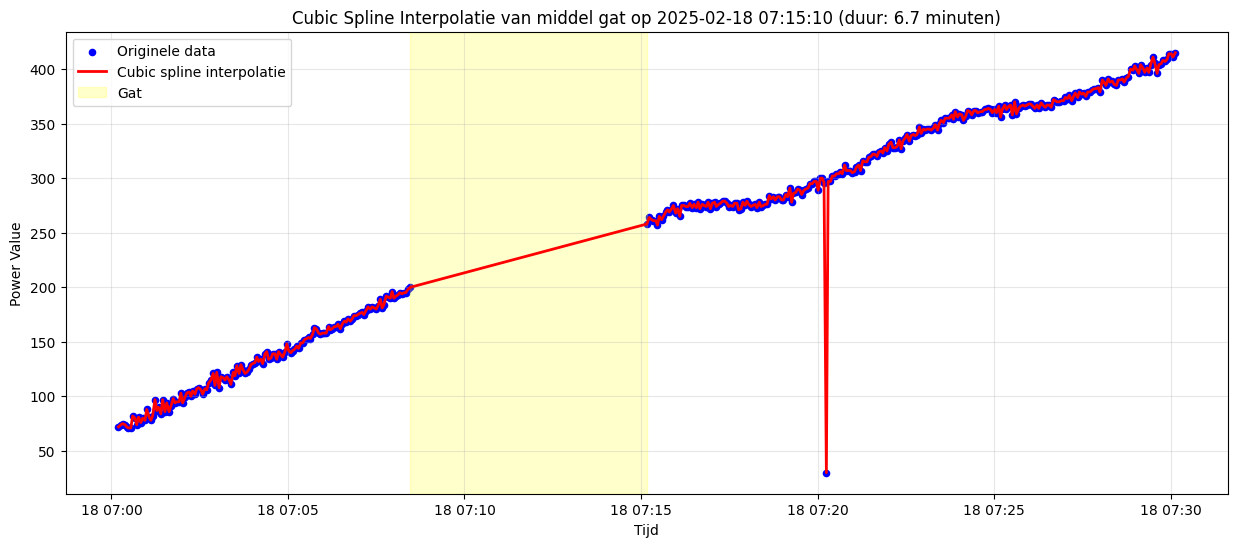

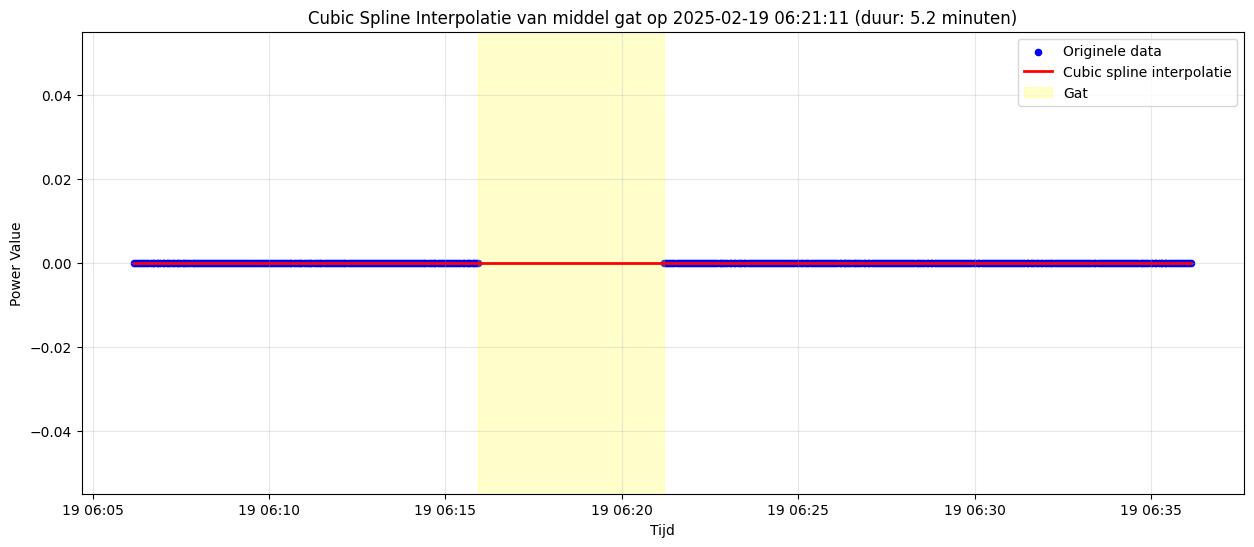

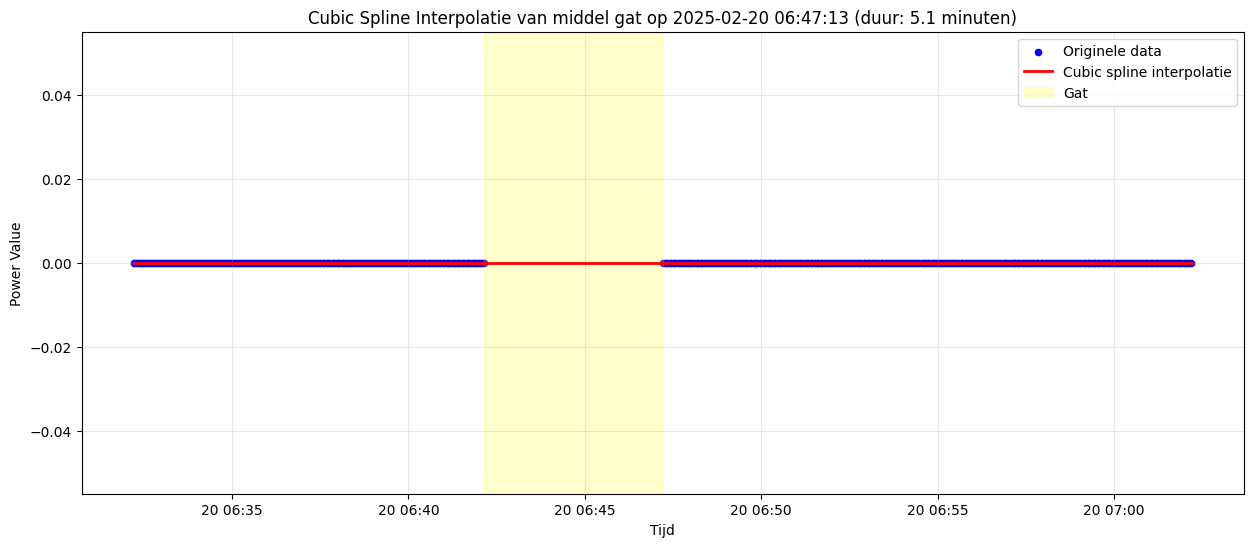

In [ ]:
def visualiseer_opgevulde_gaten(df_cleaned, df_interpolated, gap_types=["klein", "middel"], max_examples=5):
    gaten_mask = df_cleaned['gap_category'].isin(gap_types)
    gaten_datapunten = df_cleaned[gaten_mask]

    if len(gaten_datapunten) == 0:
        print(f"Geen gaten gevonden van type(s): {', '.join(gap_types)}")
        return

    print(f"Gevonden aantal gaten van type(s) {', '.join(gap_types)}: {len(gaten_datapunten)}")

    te_tonen_gaten = gaten_datapunten.head(max_examples)

    for idx, gap_row in te_tonen_gaten.iterrows():
        gap_timestamp = gap_row['Datetime']
        gap_seconds = gap_row['time_diff']
        gap_categorie = gap_row['gap_category']

        if gap_categorie == "klein":
            venster_minuten = 5
        else:  # middel of groter
            venster_minuten = max(15, gap_seconds / 60 * 2)  # Groter venster voor grotere gaten

        window_start = gap_timestamp - pd.Timedelta(minutes=venster_minuten)
        window_end = gap_timestamp + pd.Timedelta(minutes=venster_minuten)

        # Haal originele en geïnterpoleerde data voor dit venster
        original = df_cleaned[(df_cleaned['Datetime'] >= window_start) &
                             (df_cleaned['Datetime'] <= window_end)]
        interpolated = df_interpolated[(df_interpolated['Datetime'] >= window_start) &
                                     (df_interpolated['Datetime'] <= window_end)]

        # Visualiseer het originele gat en de interpolatie
        plt.figure(figsize=(15, 6))
        plt.scatter(original['Datetime'], original['Power_Value'],
                   color='blue', label='Originele data', s=20)
        plt.plot(interpolated['Datetime'], interpolated['Power_Value'],
                color='red', linewidth=2, label='Cubic spline interpolatie')

        # Markeer het gat
        gap_start = gap_timestamp - pd.Timedelta(seconds=gap_seconds)
        plt.axvspan(gap_start, gap_timestamp, color='yellow', alpha=0.2, label='Gat')

        plt.title(f'Cubic Spline Interpolatie van {gap_categorie} gat op {gap_timestamp} (duur: {gap_seconds/60:.1f} minuten)')
        plt.xlabel('Tijd')
        plt.ylabel('Power Value')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

visualiseer_opgevulde_gaten(df_cleaned, df_interpolated, gap_types=["middel"], max_examples=3)

## Feature engineering

In [ ]:
# Enorm gat even afsnijden
cutoff_date = pd.Timestamp("2025-02-27 23:59:59")
df_cutoff = df_interpolated.copy()
df_cutoff = df_cutoff[df_cutoff['Datetime'] <= cutoff_date]

print(f"Vorm van df_cutoff na filtering: {df_cutoff.shape}")

Vorm van df_cutoff na filtering: (267743, 8)


In [ ]:
df_features = df_cutoff.copy() # df_cleaned.copy()
df_features = df_features.drop(columns=['gap_category'])

# Controleer eerst het datatype van alle kolommen
print("Datatypes in de dataset:")
print(df_features.dtypes)

# Converteer eventuele categorische kolommen naar numeriek als nodig
cat_columns = df_features.select_dtypes(include=['category']).columns
for col in cat_columns:
    df_features[col] = df_features[col].astype(float)

# 1. Tijdgerelateerde cyclische features
# Uur van de dag (0-23)
df_features['hour_sin'] = np.sin(2 * np.pi * df_features['hour'] / 24)
df_features['hour_cos'] = np.cos(2 * np.pi * df_features['hour'] / 24)

# Dag van de week (0-6)
df_features['dayofweek_sin'] = np.sin(2 * np.pi * df_features['dayofweek'] / 7)
df_features['dayofweek_cos'] = np.cos(2 * np.pi * df_features['dayofweek'] / 7)

# 2. Rolling statistics
window_samples = [300 // SAMPLING_INTERVAL, 600 // SAMPLING_INTERVAL]  # ~5 min, ~10 min in samples

for window in window_samples:
    # Rolling mean - trend
    df_features[f'rolling_mean_{window}'] = df_features['Power_Value'].rolling(window=window, min_periods=1).mean()

    # Rolling std - volatiliteit
    df_features[f'rolling_std_{window}'] = df_features['Power_Value'].rolling(window=window, min_periods=1).std().fillna(0)

    # Rolling min/max - range
    df_features[f'rolling_min_{window}'] = df_features['Power_Value'].rolling(window=window, min_periods=1).min()
    df_features[f'rolling_max_{window}'] = df_features['Power_Value'].rolling(window=window, min_periods=1).max()

    # Relatieve positie binnen rolling window (waardevol voor pieken/dalen)
    min_vals = df_features['Power_Value'].rolling(window=window, min_periods=1).min()
    max_vals = df_features['Power_Value'].rolling(window=window, min_periods=1).max()
    range_vals = max_vals - min_vals
    # Vermijd deling door nul
    range_vals = range_vals.replace(0, 1)
    df_features[f'rolling_position_{window}'] = (df_features['Power_Value'] - min_vals) / range_vals

# 3. Differentiële features
# Bereken tijdsverschil in seconden
df_features['time_diff'] = df_features['Datetime'].diff().dt.total_seconds().fillna(0)
df_features['power_diff'] = df_features['Power_Value'].diff().fillna(0)
# Vermijd deling door nul
df_features['rate_of_change'] = np.where(df_features['time_diff'] > 0,
                                        df_features['power_diff'] / df_features['time_diff'],
                                        0)

# Tweede afgeleide (versnelling)
df_features['acceleration'] = df_features['rate_of_change'].diff().fillna(0) / df_features['time_diff'].replace(0, 1)

# 4. Zonne-energie specifieke features
df_features['is_daytime'] = ((df_features['hour'] >= 6) & (df_features['hour'] <= 20)).astype(float)
df_features['is_peak_sun'] = ((df_features['hour'] >= 10) & (df_features['hour'] <= 16)).astype(float)
df_features['hours_since_sunrise'] = np.where(df_features['hour'] >= 6,
                                            df_features['hour'] - 6,
                                            0)
df_features['hours_until_sunset'] = np.where(df_features['hour'] <= 20,
                                           20 - df_features['hour'],
                                           0)

# 7. Verwijder kolommen die we niet meer nodig hebben
cols_to_drop = ['time_diff', 'day', 'hour', 'month', 'dayofweek']
df_features = df_features.drop(columns=cols_to_drop, errors='ignore')

# 8. Controleer op NaN-waarden en vul ze op per kolomtype
# Voor niet-categorische kolommen
numeric_cols = df_features.select_dtypes(include=['float64', 'int64']).columns
df_features[numeric_cols] = df_features[numeric_cols].fillna(0)

# Voor datetime kolommen
datetime_cols = df_features.select_dtypes(include=['datetime64']).columns
if not datetime_cols.empty:
    for col in datetime_cols:
        df_features[col] = df_features[col].fillna(df_features[col].mean())

# Print informatie over de features
print(f"Aantal features: {len(df_features.columns)}")
print(f"Eerste paar feature kolommen: {df_features.columns[:-1].tolist()}")

# Controleer of er nog NaN-waarden zijn
nan_count = df_features.isna().sum().sum()
print(f"Aantal resterende NaN-waarden: {nan_count}")

Datatypes in de dataset:
Datetime       datetime64[ns]
Power_Value             int64
time_diff             float64
hour                  float64
day                   float64
month                 float64
dayofweek             float64
dtype: object
Aantal features: 23
Eerste paar feature kolommen: ['Datetime', 'Power_Value', 'hour_sin', 'hour_cos', 'dayofweek_sin', 'dayofweek_cos', 'rolling_mean_60', 'rolling_std_60', 'rolling_min_60', 'rolling_max_60', 'rolling_position_60', 'rolling_mean_120', 'rolling_std_120', 'rolling_min_120', 'rolling_max_120', 'rolling_position_120', 'power_diff', 'rate_of_change', 'acceleration', 'is_daytime', 'is_peak_sun', 'hours_since_sunrise']
Aantal resterende NaN-waarden: 0


In [ ]:
df_features[['Datetime', 'Power_Value']].to_csv('home_training.csv', index=False)

## Sequentievoorbereiden voor LSTM

In [ ]:
class MultiStepTimeseriesGenerator(keras.utils.Sequence):
    """
    Een aangepaste generator die meerdere tijdstappen als output genereert.
    Hiermee kunnen we een model trainen dat direct FORECAST_HORIZON stappen vooruit kan voorspellen.
    """
    def __init__(self, data, targets, length, forecast_horizon, feature_idx=0,
                 sampling_rate=1, stride=1, batch_size=32, shuffle=False,
                 start_index=0, end_index=None):
        """
        Parameters:
            data: De volledige dataset array (samples, features)
            targets: De target features (vaak hetzelfde als data)
            length: Aantal tijdstappen om terug te kijken
            forecast_horizon: Aantal stappen vooruit te voorspellen
            feature_idx: Index van de feature die voorspeld moet worden (standaard 0)
            sampling_rate: Interval tussen opeenvolgende tijdpunten
            stride: Stap tussen opeenvolgende sequences
            batch_size: Aantal samples per batch
            shuffle: Of sequenties willekeurig geordend moeten worden
            start_index: Begin van het dataset bereik om te gebruiken
            end_index: Einde van het dataset bereik om te gebruiken
        """
        self.data = data
        self.targets = targets
        self.length = length
        self.forecast_horizon = forecast_horizon
        self.feature_idx = feature_idx
        self.sampling_rate = sampling_rate
        self.stride = stride
        self.batch_size = batch_size
        self.shuffle = shuffle

        if end_index is None:
            end_index = len(data) - forecast_horizon

        self.start_index = start_index
        self.end_index = end_index

        # Bereken het aantal beschikbare sequenties
        self.available_indices = list(range(start_index + length, end_index, stride))

        if shuffle:
            np.random.shuffle(self.available_indices)

    def __len__(self):
        """Bepaal het aantal batches per epoch."""
        return len(self.available_indices) // self.batch_size

    def __getitem__(self, index):
        """Genereer één batch van data."""
        # Indices voor deze batch
        batch_indices = self.available_indices[index * self.batch_size:
                                            (index + 1) * self.batch_size]

        # Batch van input sequences initialiseren
        batch_x = np.zeros((len(batch_indices), self.length, self.data.shape[1]))

        # Batch van output sequences initialiseren (nu meerdere tijdstappen)
        batch_y = np.zeros((len(batch_indices), self.forecast_horizon))

        # Vul de batches
        for i, idx in enumerate(batch_indices):
            # Input sequence
            indices = range(idx - self.length, idx, self.sampling_rate)
            batch_x[i] = self.data[indices]

            # Output sequence (meerdere stappen vooruit)
            # We nemen alleen de target feature (standaard Power_Value op index 0)
            batch_y[i] = self.targets[idx:idx + self.forecast_horizon, self.feature_idx]

        return batch_x, batch_y

    def on_epoch_end(self):
        """Functie die wordt uitgevoerd aan het einde van elke epoch."""
        if self.shuffle:
            np.random.shuffle(self.available_indices)

In [ ]:
# Datetime kolom apart houden voor later referentie
datetime_col = df_features['Datetime']
df_features_no_date = df_features.drop(columns=['Datetime'])

# Eerst de datapunten splitsen, dan pas normaliseren
n_samples = len(df_features_no_date)
train_end_idx = int(n_samples * TRAIN_SPLIT)
val_end_idx = int(n_samples * (TRAIN_SPLIT + VAL_SPLIT))

# Split de features data
train_features = df_features_no_date.iloc[:train_end_idx]
val_features = df_features_no_date.iloc[train_end_idx:val_end_idx]
test_features = df_features_no_date.iloc[val_end_idx:]

# Initialiseer de scaler en FIT alleen op de trainingsdata
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(train_features)

# Transform alle datasets met dezelfde scaler
scaled_train = scaler.transform(train_features)
scaled_val = scaler.transform(val_features)
scaled_test = scaler.transform(test_features)

# Converteer terug naar DataFrame voor duidelijkheid (optioneel)
train_scaled_df = pd.DataFrame(scaled_train, columns=df_features_no_date.columns, index=train_features.index)
val_scaled_df = pd.DataFrame(scaled_val, columns=df_features_no_date.columns, index=val_features.index)
test_scaled_df = pd.DataFrame(scaled_test, columns=df_features_no_date.columns, index=test_features.index)

# Voeg Datetime kolommen weer toe voor referentie indien nodig
train_scaled_df['Datetime'] = datetime_col.iloc[:train_end_idx].values
val_scaled_df['Datetime'] = datetime_col.iloc[train_end_idx:val_end_idx].values
test_scaled_df['Datetime'] = datetime_col.iloc[val_end_idx:].values

# Print informatie over de datasets
print(f"Vorm van genormaliseerde trainingsset: {train_scaled_df.shape}")
print(f"Vorm van genormaliseerde validatieset: {val_scaled_df.shape}")
print(f"Vorm van genormaliseerde testset: {test_scaled_df.shape}")
print(f"Bereik van genormaliseerde Power_Value in trainingsset: [{train_scaled_df['Power_Value'].min()}, {train_scaled_df['Power_Value'].max()}]")

# Converteer de geschaalde data naar numpy arrays voor de TimeseriesGenerator
train_array = train_scaled_df.drop(columns=['Datetime']).values
val_array = val_scaled_df.drop(columns=['Datetime']).values
test_array = test_scaled_df.drop(columns=['Datetime']).values


# Maak de generators met de correcte arrays
train_generator = MultiStepTimeseriesGenerator(
    data=train_array,
    targets=train_array,
    length=LOOKBACK_WINDOW,
    forecast_horizon=FORECAST_HORIZON,
    feature_idx=0,  # Expliciet Power_Value selecteren voor voorspelling
    batch_size=BATCH_SIZE,
    shuffle=True,
    start_index=0,
    end_index=len(train_array) - FORECAST_HORIZON
)

val_generator = MultiStepTimeseriesGenerator(
    data=val_array,
    targets=val_array,
    length=LOOKBACK_WINDOW,
    forecast_horizon=FORECAST_HORIZON,
    feature_idx=0,
    batch_size=BATCH_SIZE,
    shuffle=False,
    start_index=0,
    end_index=len(val_array) - FORECAST_HORIZON
)

test_generator = MultiStepTimeseriesGenerator(
    data=test_array,
    targets=test_array,
    length=LOOKBACK_WINDOW,
    forecast_horizon=FORECAST_HORIZON,
    feature_idx=0,
    batch_size=BATCH_SIZE,
    shuffle=False,
    start_index=0,
    end_index=len(test_array) - FORECAST_HORIZON
)

print(f"Aantal batches in trainingsset: {len(train_generator)}")
print(f"Aantal batches in validatieset: {len(val_generator)}")
print(f"Aantal batches in testset: {len(test_generator)}")

Vorm van genormaliseerde trainingsset: (15119, 23)
Vorm van genormaliseerde validatieset: (3241, 23)
Vorm van genormaliseerde testset: (3240, 23)
Bereik van genormaliseerde Power_Value in trainingsset: [0.0, 1.0]
Aantal batches in trainingsset: 150
Aantal batches in validatieset: 31
Aantal batches in testset: 31


In [ ]:
print(test_scaled_df.columns)

Index(['Power_Value', 'hour_sin', 'hour_cos', 'dayofweek_sin', 'dayofweek_cos',
       'rolling_mean_5', 'rolling_std_5', 'rolling_min_5', 'rolling_max_5',
       'rolling_position_5', 'rolling_mean_10', 'rolling_std_10',
       'rolling_min_10', 'rolling_max_10', 'rolling_position_10', 'power_diff',
       'rate_of_change', 'acceleration', 'is_daytime', 'is_peak_sun',
       'hours_since_sunrise', 'hours_until_sunset', 'Datetime'],
      dtype='object')


## LSTM modelontwerp

In [ ]:
def build_multistep_lstm_model(input_shape, output_steps=FORECAST_HORIZON, lstm_units=32, dropout_rate=0.2):
    """
    Bouwt een LSTM-model dat direct meerdere stappen vooruit kan voorspellen.
    """
    model = Sequential()

    # Eerste LSTM-laag
    model.add(RNN(
        LSTMCell(lstm_units, implementation=1),
        return_sequences=True,
        input_shape=input_shape
    ))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))

    # Tweede LSTM-laag
    model.add(RNN(
        LSTMCell(lstm_units, implementation=1),
        return_sequences=False,
    ))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))

    # Dense uitvoerlaag met output_steps neuronen (voor elke voorspelde stap één)
    model.add(Dense(output_steps))

    # Compileer
    optimizer = Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

    return model

# Vorm van de input voor het model [tijdstappen_input, aantal_features]
input_shape = (LOOKBACK_WINDOW, train_array.shape[1])

# Bouw het model met 1 output in plaats van FORECAST_HORIZON outputs
model = build_multistep_lstm_model(
    input_shape=input_shape
)

# Toon modeloverzicht
model.summary()

# Voeg een eenvoudige grid search toe
"""lstm_units_options = [32, 64, 128]
dropout_rates = [0.2, 0.3, 0.4]
learning_rates = [0.001, 0.0005]

best_val_loss = float('inf')
best_params = {}

for units in lstm_units_options:
    for dropout in dropout_rates:
        for lr in learning_rates:
            print(f"Training met units={units}, dropout={dropout}, lr={lr}")

            # Model met deze parameters
            LSTM_UNITS = units
            DROPOUT_RATE = dropout
            LEARNING_RATE = lr

            model = build_lstm_model(
                input_shape=(LOOKBACK_WINDOW, train_array.shape[1]),
                output_length=1,
                lstm_units=LSTM_UNITS,
                dropout_rate=DROPOUT_RATE
            )

            # Train met early stopping
            es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
            history = model.fit(
                train_generator,
                epochs=20,  # Minder epochs voor snellere search
                validation_data=val_generator,
                callbacks=[es],
                verbose=1
            )

            # Check of dit beter is
            final_val_loss = min(history.history['val_loss'])
            if final_val_loss < best_val_loss:
                best_val_loss = final_val_loss
                best_params = {
                    'units': units,
                    'dropout': dropout,
                    'learning_rate': lr
                }

            # Maak geheugen vrij
            tf.keras.backend.clear_session()

print(f"Beste parameters: {best_params}, val_loss: {best_val_loss}")"""

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rnn_2 (RNN)                     │ (None, 12, 32)         │         7,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_3 (RNN)                     │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 60)             │         1,980 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,596 (68.73 KB)

 Trainable params: 17,468 (68.23 KB)

 Non-trainable params: 128 (512.00 B)

'lstm_units_options = [32, 64, 128]\ndropout_rates = [0.2, 0.3, 0.4]\nlearning_rates = [0.001, 0.0005]\n\nbest_val_loss = float(\'inf\')\nbest_params = {}\n\nfor units in lstm_units_options:\n    for dropout in dropout_rates:\n        for lr in learning_rates:\n            print(f"Training met units={units}, dropout={dropout}, lr={lr}")\n\n            # Model met deze parameters\n            LSTM_UNITS = units\n            DROPOUT_RATE = dropout\n            LEARNING_RATE = lr\n\n            model = build_lstm_model(\n                input_shape=(LOOKBACK_WINDOW, train_array.shape[1]),\n                output_length=1,\n                lstm_units=LSTM_UNITS,\n                dropout_rate=DROPOUT_RATE\n            )\n\n            # Train met early stopping\n            es = EarlyStopping(monitor=\'val_loss\', patience=5, restore_best_weights=True)\n            history = model.fit(\n                train_generator,\n                epochs=20,  # Minder epochs voor snellere search\n     

## Training en validatie

In [ ]:
# Callbacks voor tijdens de training
callbacks = [
    # Early stopping om training te stoppen als er geen verbetering meer is
    EarlyStopping(
        monitor='val_loss',  # Kijk naar de validatie loss
        patience=4,         # Wacht 10 epochs voordat je stopt
        restore_best_weights=True,  # Herstel de beste gewichten
        verbose=1
    ),

    # ModelCheckpoint om het beste model op te slaan
    ModelCheckpoint(
        filepath=MODEL_SAVE_PATH,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),

    # ReduceLROnPlateau om de leersnelheid te verminderen als het model stagneert
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

# Train het model met generators
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


145/150 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4653 - mae: 0.5184
Epoch 1: val_loss improved from inf to 0.03545, saving model to ./models/home_lstm_model.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 0.4573 - mae: 0.5132 - val_loss: 0.0354 - val_mae: 0.1419 - learning_rate: 0.0010
Epoch 2/10
145/150 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0903 - mae: 0.2342
Epoch 2: val_loss improved from 0.03545 to 0.01119, saving model to ./models/home_lstm_model.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0897 - mae: 0.2334 - val_loss: 0.0112 - val_mae: 0.0838 - learning_rate: 0.0010
Epoch 3/10
145/150 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0436 - mae: 0.1610
Epoch 3: val_loss improved from 0.01119 to 0.00653, saving model to ./models/home_lstm_model.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0434 - mae: 0.1605 - val_loss: 0.0065 - val_mae: 0.0572 - learning_rate: 0.0010
Epoch 4/10
146/150 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0244 - mae: 0.1188

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.experimental_enable_resource_variables = True

# Add these two lines to fix the error
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS, tf.lite.OpsSet.SELECT_TF_OPS]
converter._experimental_lower_tensor_list_ops = False

try:
    tflite_model = converter.convert()
    # Sla het TFLite model op
    with open('baseline_model.tflite', 'wb') as f:
        f.write(tflite_model)
    print("Model succesvol geconverteerd en opgeslagen!")
except Exception as e:
    print(f"Conversie mislukt met error: {e}")

Saved artifact at '/tmp/tmpw_extsqr'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 12, 22), dtype=tf.float32, name='keras_tensor_29')
Output Type:
  TensorSpec(shape=(None, 60), dtype=tf.float32, name=None)
Captures:
  133178884721552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133178884722320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133178884722128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133177279207120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133177279207696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133178884722512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133178884722704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133177279207312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133177279208464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133177279212304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133177279206736

In [ ]:
#files.download('model.tflite')

## Evaluatie en validatie

In [ ]:
def evaluate_multistep_model(model, test_generator, scaler, num_samples=10):
    """
    Evalueert het multi-step model op de testset.
    """
    mse_scores = []
    mae_scores = []
    r2_scores = []
    true_values_all = []
    predicted_values_all = []

    # Beperk tot num_samples of het beschikbare aantal
    num_samples = min(num_samples, len(test_generator))

    for i in range(num_samples):
        x_batch, y_batch = test_generator[i]

        for j in range(min(len(x_batch), 2)):  # Beperk tot 2 voorbeelden per batch
            # Voorspel direct alle stappen
            input_seq = x_batch[j:j+1]  # Behoud dimensies met slice [j:j+1]
            predictions = model.predict(input_seq, verbose=0)[0]

            # Haal werkelijke waarden op
            true_values = y_batch[j]

            # Schaal terug naar originele waarden
            dummy_pred = np.zeros((len(predictions), train_array.shape[1]))
            dummy_pred[:, 0] = predictions
            predictions_orig = scaler.inverse_transform(dummy_pred)[:, 0]

            dummy_true = np.zeros((len(true_values), train_array.shape[1]))
            dummy_true[:, 0] = true_values
            true_values_orig = scaler.inverse_transform(dummy_true)[:, 0]

            # Bereken metrics
            mse = mean_squared_error(true_values_orig, predictions_orig)
            mae = mean_absolute_error(true_values_orig, predictions_orig)
            r2 = r2_score(true_values_orig, predictions_orig)

            mse_scores.append(mse)
            mae_scores.append(mae)
            r2_scores.append(r2)
            true_values_all.append(true_values_orig)
            predicted_values_all.append(predictions_orig)

    # Print gemiddelde metrics
    print(f"Multi-step model evaluatie:")
    print(f"Gemiddelde MSE: {np.mean(mse_scores):.2f}")
    print(f"Gemiddelde MAE: {np.mean(mae_scores):.2f}")
    print(f"Gemiddelde R²: {np.mean(r2_scores):.4f}")

    return true_values_all, predicted_values_all

def visualize_multistep_predictions(true_values, predicted_values, idx=None):
    """
    Visualiseert de multi-step voorspellingen.
    """
    if len(true_values) == 0:
        print("Geen voorspellingen beschikbaar om te visualiseren.")
        return

    if idx is None:
        idx = np.random.randint(0, len(true_values))
    else:
        idx = min(idx, len(true_values)-1)

    # Bereken metrics voor dit specifieke voorbeeld
    mse = mean_squared_error(true_values[idx], predicted_values[idx])
    mae = mean_absolute_error(true_values[idx], predicted_values[idx])

    # Tijdlabels in minuten voor duidelijkere visualisatie
    minute_labels = [i*SAMPLING_INTERVAL/60 for i in range(len(true_values[idx]))]

    plt.figure(figsize=(15, 6))
    plt.plot(minute_labels, true_values[idx], 'b-', label='Werkelijke waarden')
    plt.plot(minute_labels, predicted_values[idx], 'r-', label='Voorspellingen')
    plt.title(f'1-uur multi-step voorspelling vs. werkelijke waarden (MSE: {mse:.2f}, MAE: {mae:.2f})')
    plt.xlabel('Tijd (minuten)')
    plt.ylabel('Power Value')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Toon ook de absolute fout
    plt.figure(figsize=(15, 4))
    error = np.abs(true_values[idx] - predicted_values[idx])
    plt.plot(minute_labels, error, 'g-', label='Absolute fout')
    plt.title(f'Absolute voorspellingsfout')
    plt.xlabel('Tijd (minuten)')
    plt.ylabel('Absolute fout')
    plt.grid(True)
    plt.axhline(y=mae, color='r', linestyle='--', label=f'Gemiddelde fout: {mae:.2f}')
    plt.legend()
    plt.show()

Start evaluatie van het multi-step model...
Multi-step model evaluatie:
Gemiddelde MSE: 70966426.52
Gemiddelde MAE: 3988.30
Gemiddelde R²: -81.8369
Evaluatie voltooid. 20 voorspellingen geanalyseerd.
Visualisatie van een willekeurige voorspelling:


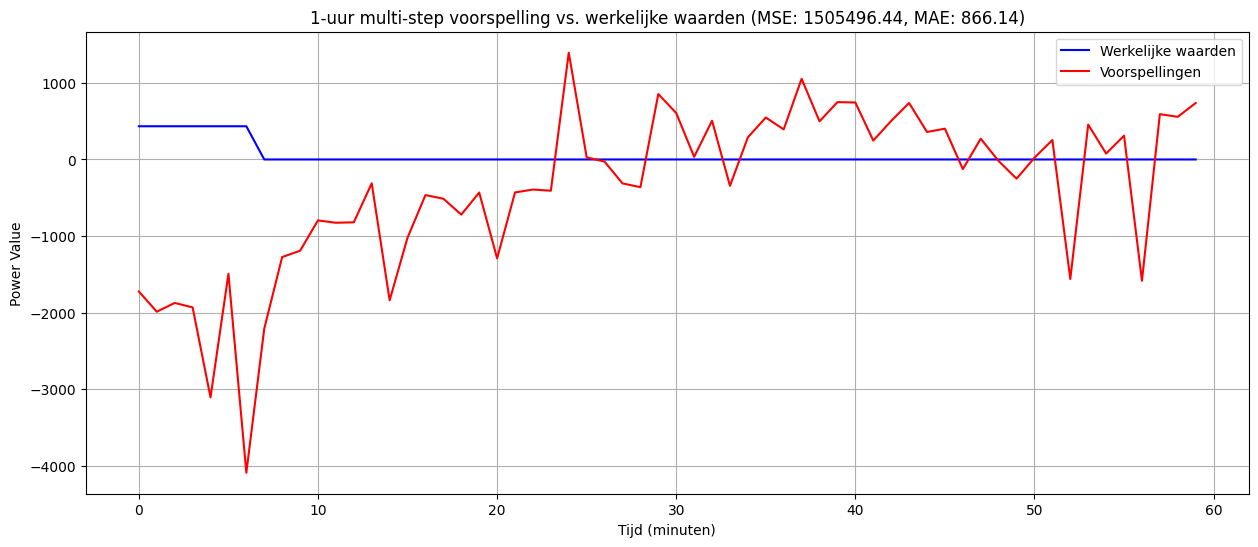

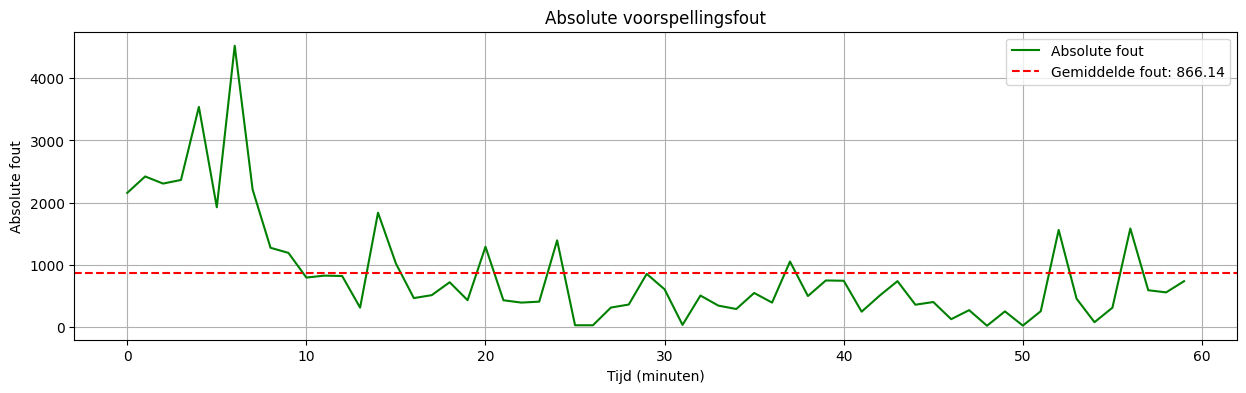


Beste voorspelling (laagste MSE = 340174.59):


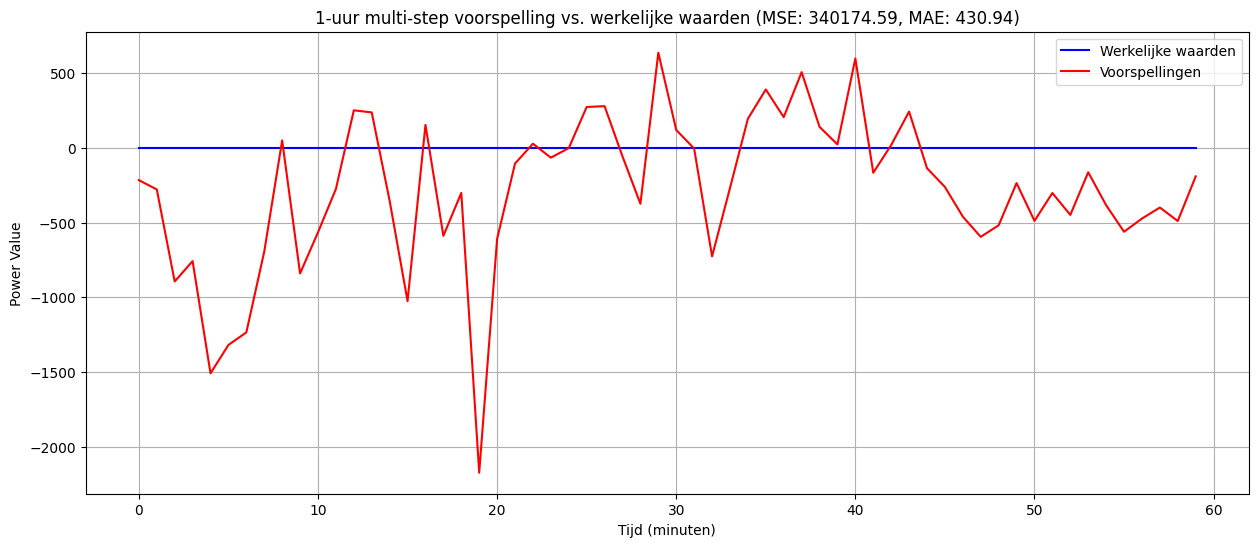

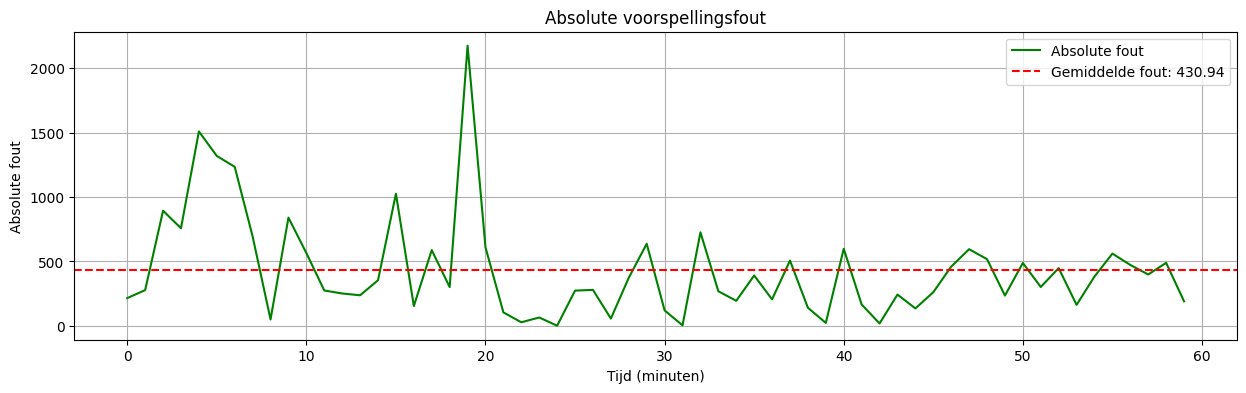


Slechtste voorspelling (hoogste MSE = 523774386.03):


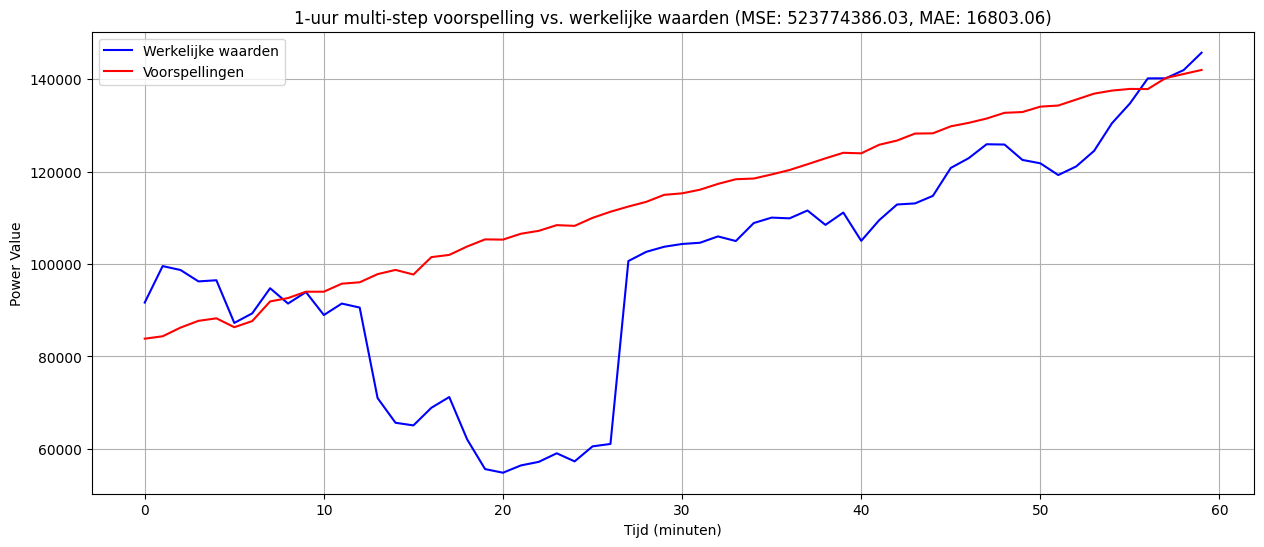

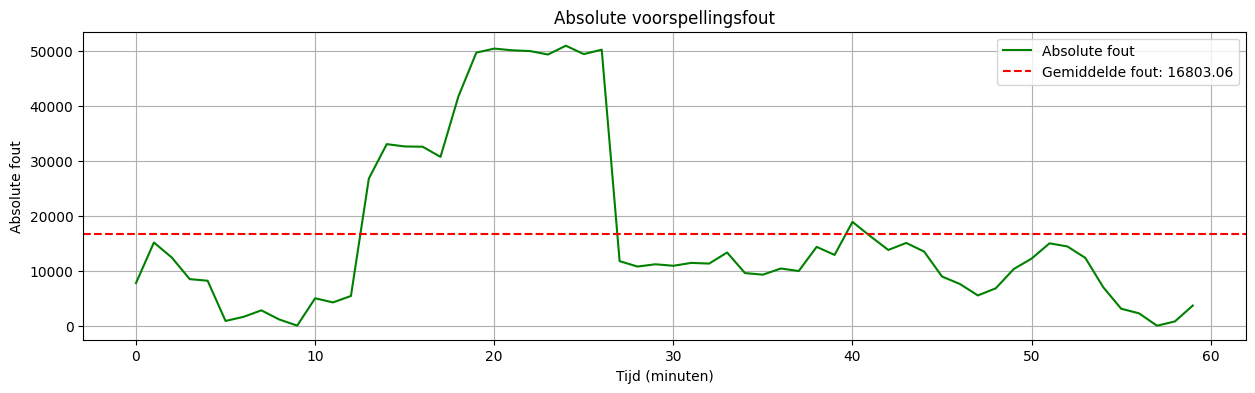

In [ ]:
# Evalueer het multi-step model
print("Start evaluatie van het multi-step model...")
true_values, pred_values = evaluate_multistep_model(model, test_generator, scaler, num_samples=10)
print(f"Evaluatie voltooid. {len(true_values)} voorspellingen geanalyseerd.")

# Visualiseer een willekeurige voorspelling
if len(true_values) > 0:
    print("Visualisatie van een willekeurige voorspelling:")
    visualize_multistep_predictions(true_values, pred_values)

    # Toon ook het beste en slechtste voorbeeld
    if len(true_values) > 1:
        # Bereken MSE voor elke voorspelling
        mse_per_prediction = [mean_squared_error(true_values[i], pred_values[i]) for i in range(len(true_values))]
        best_idx = np.argmin(mse_per_prediction)
        worst_idx = np.argmax(mse_per_prediction)

        print(f"\nBeste voorspelling (laagste MSE = {mse_per_prediction[best_idx]:.2f}):")
        visualize_multistep_predictions(true_values, pred_values, best_idx)

        print(f"\nSlechtste voorspelling (hoogste MSE = {mse_per_prediction[worst_idx]:.2f}):")
        visualize_multistep_predictions(true_values, pred_values, worst_idx)

## Dynamic range kwantisatie

In [ ]:
print("\n--- Dynamic-range kwantisatie (met extra flags) ---")
dynamic_range_converter = tf.lite.TFLiteConverter.from_keras_model(model)
dynamic_range_converter.optimizations = [tf.lite.Optimize.DEFAULT]


dynamic_range_converter.experimental_enable_resource_variables = True
dynamic_range_converter._experimental_lower_tensor_list_ops = False
dynamic_range_converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS # DIT ZORGT VOOR MINIMIEME KWANTISATIE
]

try:
    print("Bezig met converteren naar dynamic-range model...")
    dynamic_range_model = dynamic_range_converter.convert()

    # Model opslaan
    model_filename = "lstm_dynamic_range.tflite"
    with open(model_filename, "wb") as f:
        f.write(dynamic_range_model)

    print(f"Dynamic-range model opgeslagen als: {model_filename}")
    print(f"Dynamic-range model grootte: {len(dynamic_range_model) / 1024:.2f} KB")

except Exception as e:
    print(f"Fout bij dynamic-range kwantisatie: {e}")



--- Dynamic-range kwantisatie (met extra flags) ---
Bezig met converteren naar dynamic-range model...
Saved artifact at '/tmp/tmp0m9oyljq'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 12, 22), dtype=tf.float32, name='keras_tensor_29')
Output Type:
  TensorSpec(shape=(None, 60), dtype=tf.float32, name=None)
Captures:
  133178884721552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133178884722320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133178884722128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133177279207120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133177279207696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133178884722512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133178884722704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133177279207312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133177279208464: TensorSpec(shape=(), dtype=tf.resou

## Full INT8 kwantisatie

In [ ]:
# Full INT8 kwantisatie
print("\n--- Full INT8 kwantisatie ---")

# Representatieve dataset definiëren voor kwantisatie met train_generator
def representative_dataset_gen():
    """
    Genereert representatieve samples voor kwantisatie.
    Gebruikt de eerste batch van de train_generator en levert individuele samples.
    """
    # Haal één batch uit de train_generator
    batch_x, batch_y = next(iter(train_generator))

    # Gebruik maximaal 100 samples uit deze batch voor kwantisatie
    for i in range(min(len(batch_x), 100)):
        # We hebben alleen de input nodig (batch_x) voor kwantisatie
        sample = batch_x[i:i+1].astype(np.float32)
        yield [sample]

# Configureer de converter met SELECT_TF_OPS
full_int8_converter = tf.lite.TFLiteConverter.from_keras_model(model)
full_int8_converter.optimizations = [tf.lite.Optimize.DEFAULT]
full_int8_converter.representative_dataset = representative_dataset_gen

# Belangrijke wijzigingen hier:
full_int8_converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8,
    tf.lite.OpsSet.SELECT_TF_OPS
]
full_int8_converter._experimental_lower_tensor_list_ops = False
full_int8_converter.experimental_enable_resource_variables = True

# Je kunt inference types nog steeds instellen
full_int8_converter.inference_input_type = tf.int8
full_int8_converter.inference_output_type = tf.int8

try:
    print("Bezig met converteren naar Full INT8 model...")
    full_int8_quantized_model = full_int8_converter.convert()

    # Full INT8 model opslaan
    tflite_model_filename = "lstm_full_int8.tflite"
    with open(tflite_model_filename, "wb") as f:
        f.write(full_int8_quantized_model)

    # Model grootte bekijken
    original_size = len(tflite_model) if 'litert_model' in locals() else "onbekend"
    int8_size = len(full_int8_quantized_model)

    print(f"Full INT8 TFLite model opgeslagen als: {tflite_model_filename}")
    print(f"Full INT8 TFLite model grootte: {int8_size / 1024:.2f} KB")

    if isinstance(original_size, int):
        print(f"Reductie t.o.v. ongeoptimaliseerd model: {(1 - int8_size / original_size) * 100:.2f}%")

except Exception as e:
    print(f"Fout bij het converteren naar Full INT8: {e}")
    print("Dit kan gebeuren als je model bewerkingen bevat die geen INT8 ondersteunen")
    print("Suggestie: Probeer eerst dynamic-range kwantisatie toe te passen")


--- Full INT8 kwantisatie ---
Bezig met converteren naar Full INT8 model...
Saved artifact at '/tmp/tmp18jxf9wt'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 12, 22), dtype=tf.float32, name='keras_tensor_29')
Output Type:
  TensorSpec(shape=(None, 60), dtype=tf.float32, name=None)
Captures:
  133178884721552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133178884722320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133178884722128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133177279207120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133177279207696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133178884722512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133178884722704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133177279207312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133177279208464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13317727

/usr/local/lib/python3.11/dist-packages/tensorflow/lite/python/convert.py:997: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Full INT8 TFLite model opgeslagen als: lstm_full_int8.tflite
Full INT8 TFLite model grootte: 57.73 KB


In [ ]:
print("\n=== MODEL OPTIMALISATIE EVALUATIE ===")

# Optioneel: als je een scaler gebruikt
# from sklearn.preprocessing import MinMaxScaler
# scaler = ...  # Je gebruikte scaler hier laden indien nodig

models_to_test = {
    'baseline': 'baseline_model.tflite',
    'dynamic_range': 'lstm_dynamic_range.tflite',
    'full_int8': 'lstm_full_int8.tflite'
}

results = {}

for model_name, model_file in models_to_test.items():
    if os.path.exists(model_file):
        print(f"\n--- Testing {model_name} ---")

        model_size_mb = os.path.getsize(model_file) / (1024 * 1024)
        interpreter = tf.lite.Interpreter(model_path=model_file)
        interpreter.allocate_tensors()

        input_details = interpreter.get_input_details()
        output_details = interpreter.get_output_details()

        total_mse = 0.0
        total_samples = 0
        total_inference_time = 0.0

        for test_batch_x, test_batch_y in test_generator:
            batch_size = len(test_batch_x)
            for i in range(batch_size):
                input_sample = test_batch_x[i:i+1]
                target_sample = test_batch_y[i]

                # Start timing
                start_time = time.time()

                if input_details[0]['dtype'] == np.int8:
                    input_scale, input_zero_point = input_details[0]['quantization']
                    quantized_input = np.round(input_sample / input_scale + input_zero_point).astype(np.int8)
                    interpreter.set_tensor(input_details[0]['index'], quantized_input)
                else:
                    interpreter.set_tensor(input_details[0]['index'], input_sample.astype(np.float32))

                interpreter.invoke()
                prediction = interpreter.get_tensor(output_details[0]['index'])

                if output_details[0]['dtype'] == np.int8:
                    output_scale, output_zero_point = output_details[0]['quantization']
                    prediction = (prediction.astype(np.float32) - output_zero_point) * output_scale

                inference_time = time.time() - start_time
                total_inference_time += inference_time

                prediction = prediction[0]

                # Optioneel: terugschalen naar originele eenheden
                prediction = scaler.inverse_transform(prediction.reshape(-1, 1)).flatten()
                target_sample = scaler.inverse_transform(target_sample.reshape(-1, 1)).flatten()

                mse = np.mean((prediction - target_sample)**2)
                total_mse += mse
                total_samples += 1

        avg_inference_time_ms = (total_inference_time / total_samples) * 1000
        avg_mse = total_mse / total_samples

        results[model_name] = {
            'size_mb': model_size_mb,
            'inference_time_ms': avg_inference_time_ms,
            'mse': avg_mse
        }

        print(f"Grootte: {model_size_mb:.2f} MB")
        print(f"Gemiddelde inferentietijd: {avg_inference_time_ms:.2f} ms")
        print(f"Gemiddelde MSE: {avg_mse:.6f}")
    else:
        print(f"Modelbestand niet gevonden: {model_file}")

# Vergelijkingstabel
print("\n=== VERGELIJKINGSTABEL ===")
print(f"{'Model':<15} {'Grootte (MB)':<12} {'Inferentie (ms)':<15} {'MSE':<10}")
print("-" * 60)
for model_name, stats in results.items():
    print(f"{model_name:<15} {stats['size_mb']:<12.2f} {stats['inference_time_ms']:<15.2f} {stats['mse']:<10.6f}")

# Opslaan
import json
with open('model_optimization_results.json', 'w') as f:
    json.dump(results, f, indent=2)
print("\nResultaten opgeslagen in 'model_optimization_results.json'")


=== MODEL OPTIMALISATIE EVALUATIE ===

--- Testing baseline ---
Grootte: 0.05 MB
Inferentie tijd: 0.48 ms
MSE: 0.000410

--- Testing dynamic_range ---
Grootte: 0.05 MB
Inferentie tijd: 0.54 ms
MSE: 0.000410

--- Testing full_int8 ---
Grootte: 0.06 MB
Inferentie tijd: 0.69 ms
MSE: 0.000546

=== VERGELIJKINGSTABEL ===
Model           Grootte (MB) Inferentie (ms) MSE       
------------------------------------------------------------
baseline        0.05         0.48            0.000410  
dynamic_range   0.05         0.54            0.000410  
full_int8       0.06         0.69            0.000546  

Dynamic range vs Baseline:
  Size reduction: 0.0%
  Speed improvement: -11.1%
  Accuracy change: +0.0%

Full INT8 vs Baseline:
  Size reduction: -5.8%
  Speed improvement: -30.1%
  Accuracy change: +33.2%

Resultaten opgeslagen in 'model_optimization_results.json'
